In [2]:
# --- Load disk model and M33 center once (for repeated fast use) ---
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

diskmodel = Table.read("./Kam2017_table4.dat", format='ascii')
m33coord = SkyCoord(ra=23.4621 * u.deg, dec=30.6602 * u.deg)

# --- Your full M33 stellar workflow ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from funcs import *

# === Load and preprocess primary photometric catalog ===
with fits.open("./pandas_goodstar_bright_sr.fits") as hdul:
    data = hdul[1].data
    panda = pd.DataFrame(data.astype(data.dtype.newbyteorder('=')))

panda = panda.rename(columns={'RA': 'RA_DEG', 'Dec': 'DEC_DEG'})


# === Compute deprojected radius with tilted ring model ===
panda = compute_deprojected_radius_tilted_ring(panda, diskmodel, m33coord)


# === Compute non-deprojected (projected) radius ===
distance_kpc = 859
center = m33coord
stars = SkyCoord(ra=panda['RA_DEG'].values * u.deg, dec=panda['DEC_DEG'].values * u.deg)
separation_rad = center.separation(stars).radian
panda['projected_radius_kpc'] = separation_rad * distance_kpc

# === Add CMD photometry ===
panda['color'] = panda['g'] - panda['i']
panda['mag'] = panda['i']

# === Print summary ===
print(f"RA range:  {panda['RA_DEG'].min():.4f}° to {panda['RA_DEG'].max():.4f}°")
print(f"Dec range: {panda['DEC_DEG'].min():.4f}° to {panda['DEC_DEG'].max():.4f}°")
print(f"Deprojected radius: {panda['r_deproj_kpc'].min():.2f} to {panda['r_deproj_kpc'].max():.2f} kpc")
print(f"Projected radius:    {panda['projected_radius_kpc'].min():.2f} to {panda['projected_radius_kpc'].max():.2f} kpc")
print(f"Number of stars: {len(panda):,}")

# === Save processed DataFrame as a new CSV file ===
panda.to_csv("panda_deproj.csv", index=False)

# === Load classified stars for overlay ===
df = load_filtered_fits("/Users/calvinsridhara/Documents/GitHub/M33_Analysis/Tables/m33_vels_stars_inc22B_donedupes.fits")
df = remove_high_vcorr_stars(df)
df = classify_age_groups(df)
df = compute_deprojected_radius_tilted_ring(df, diskmodel, m33coord)
df = df[(df['g'].notnull()) & (df['i'].notnull())].copy()
df['color'] = df['g'] - df['i']
df['mag'] = df['i']

IndexError: tuple index out of range

C:\Users\CoolG\AppData\Local\Temp\ipykernel_17876\2550554157.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


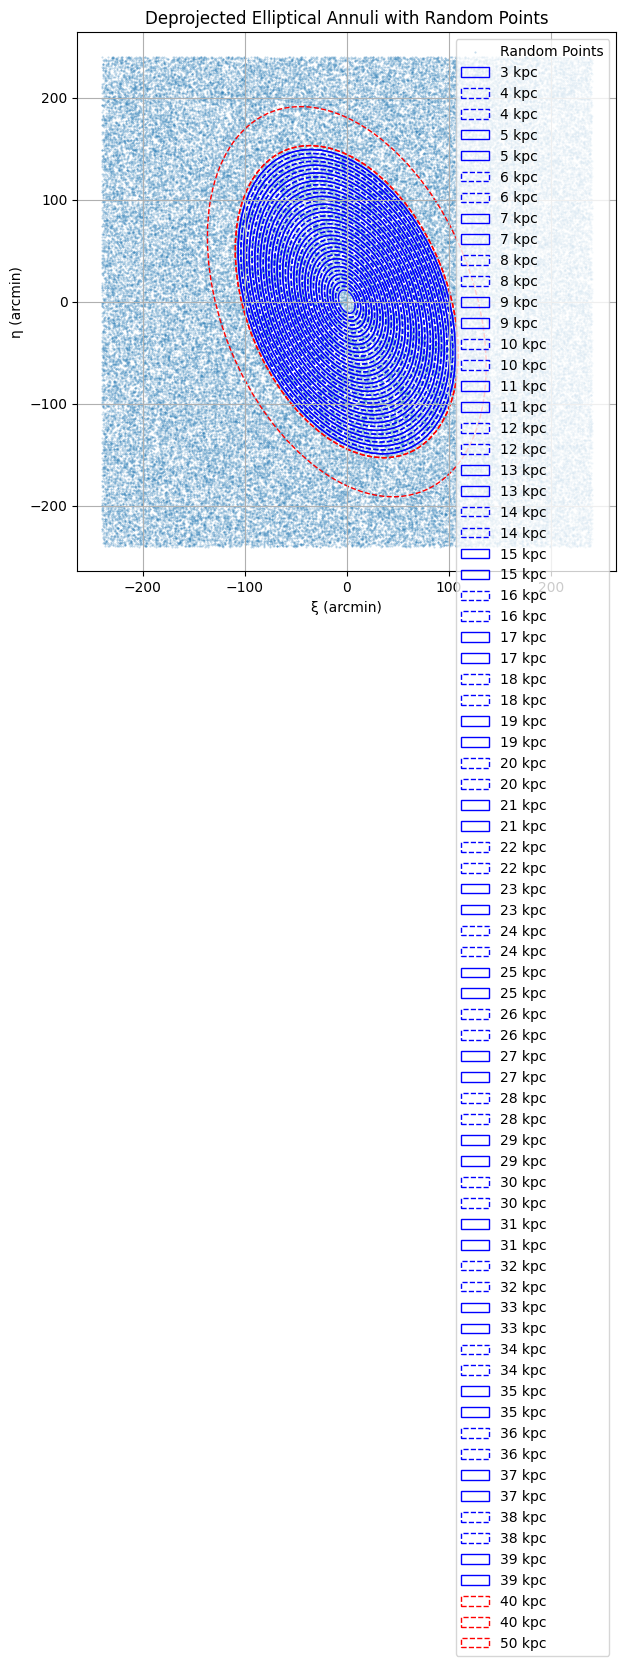


=== Area Comparison for All Bins ===
Bin (kpc)           Analytic Area          Monte Carlo Area     % Diff
---------------------------------------------------------------------------
3-4                         13.54                     13.10      -3.21
4-5                         17.41                     16.70      -4.04
5-6                         21.28                     19.44      -8.63
6-7                         25.14                     26.78       6.52
7-8                         29.01                     27.94      -3.71
8-9                         32.88                     28.94     -11.97
9-10                        36.75                     36.72      -0.08
10-11                       40.62                     39.02      -3.92
11-12                       44.49                     41.47      -6.77
12-13                       48.35                     45.22      -6.49
13-14                       52.22                     54.58       4.51
14-15                       56.09 

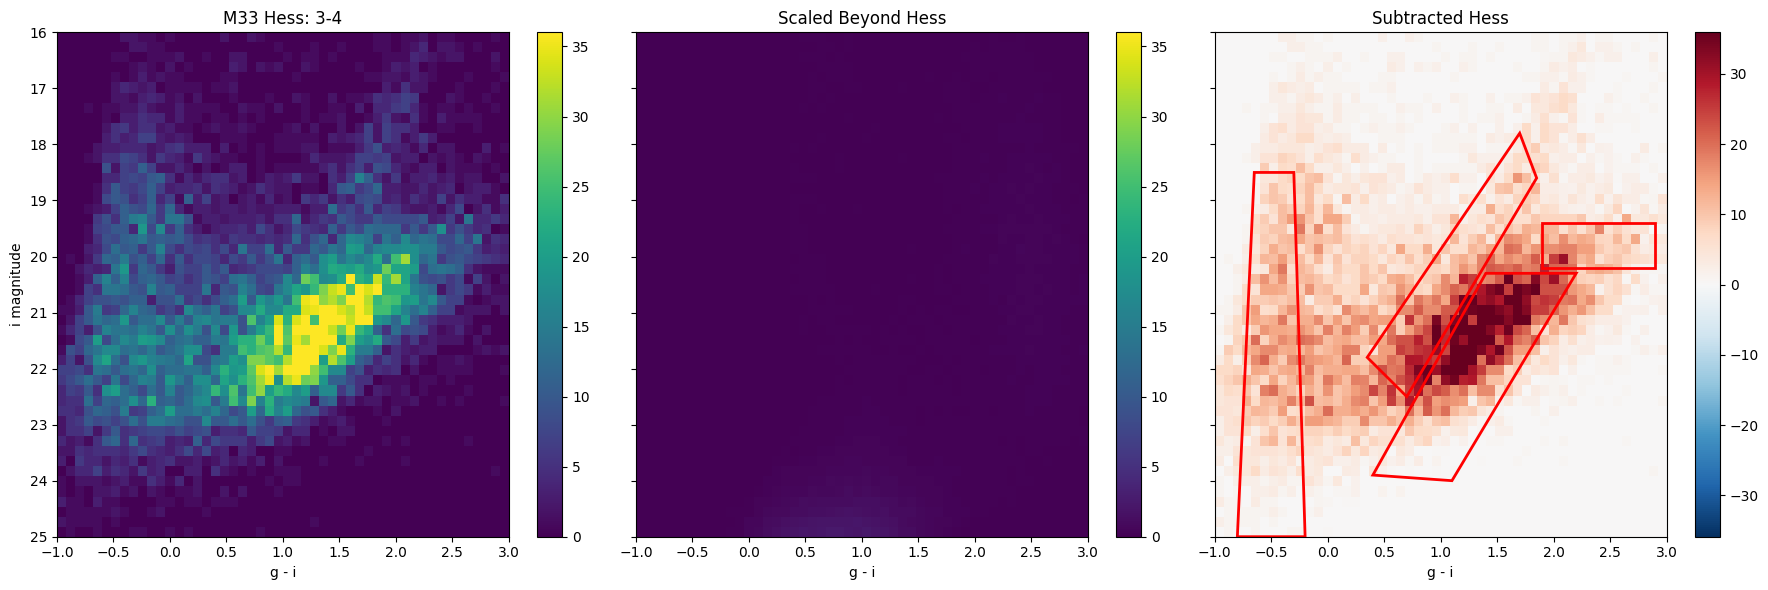

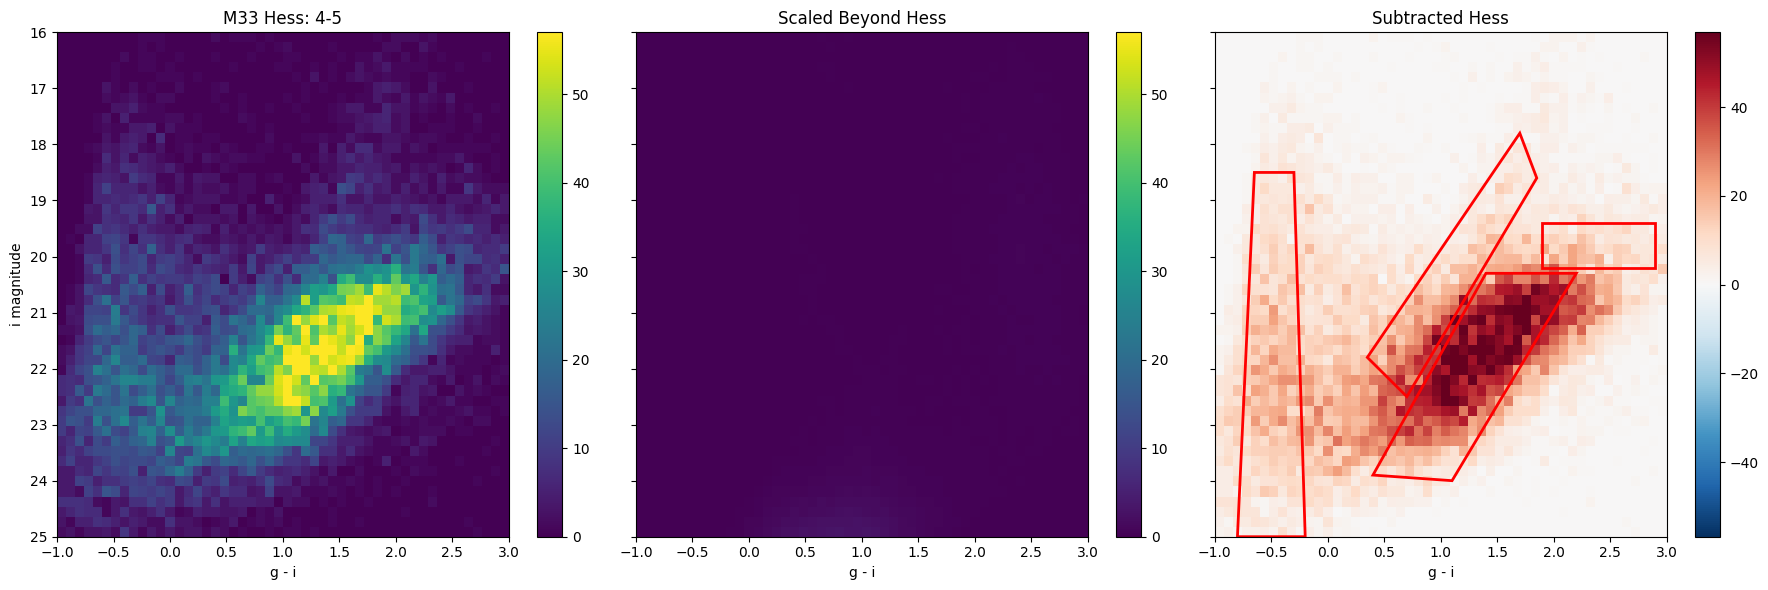

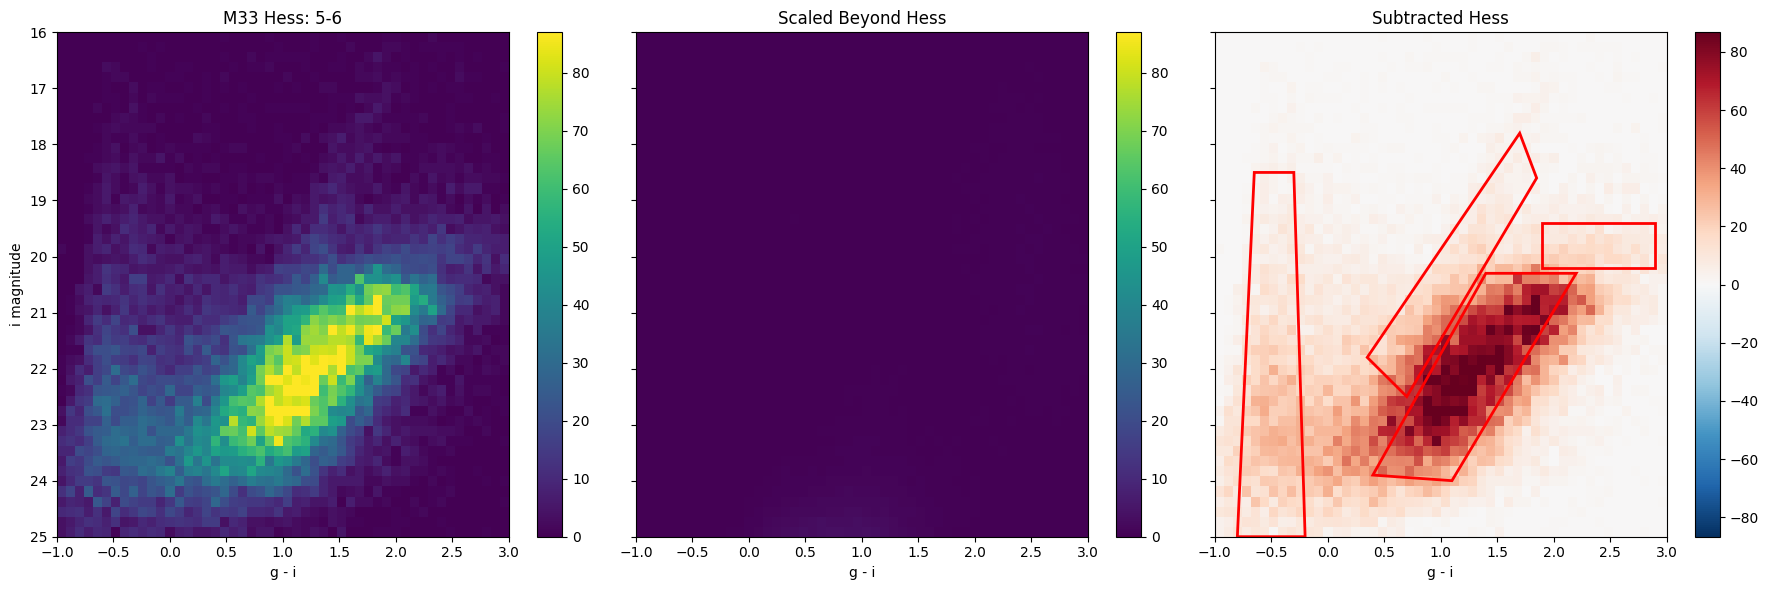

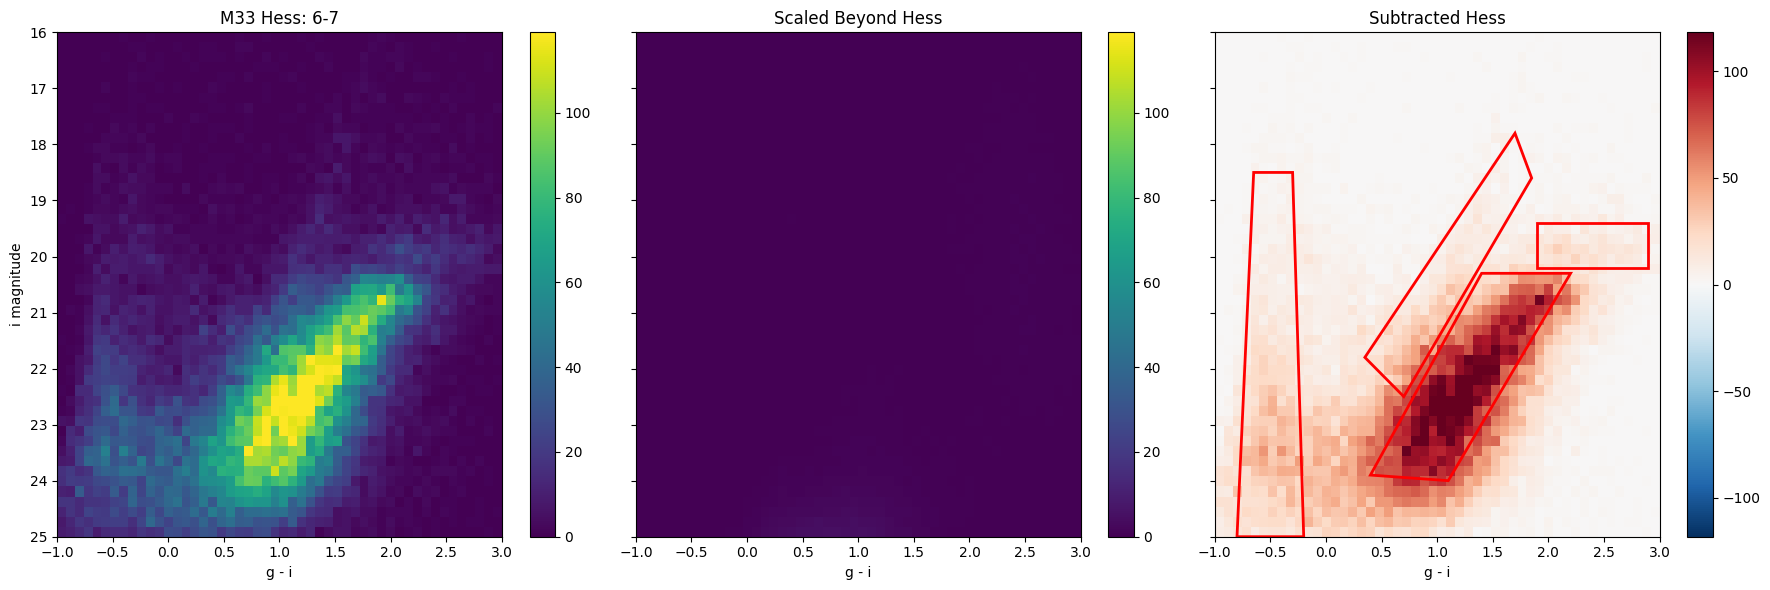

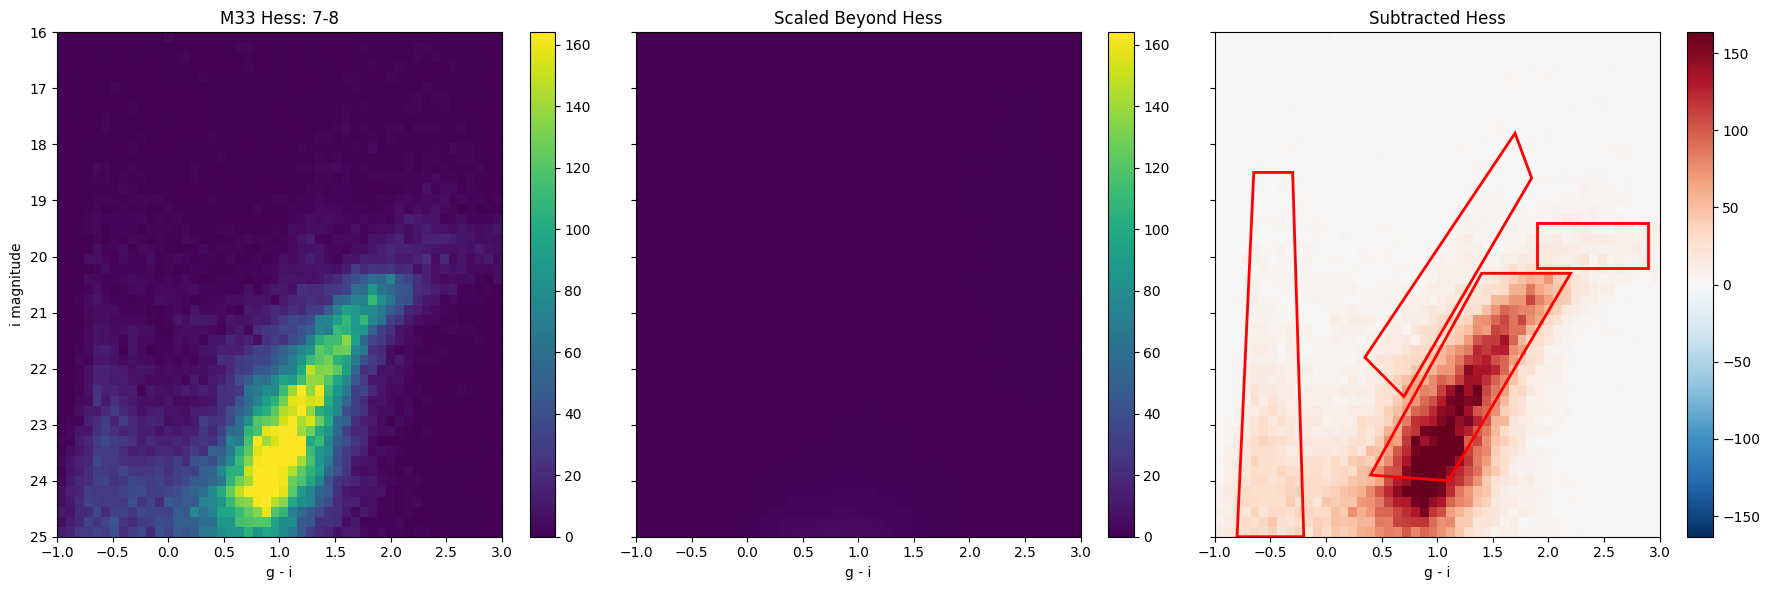

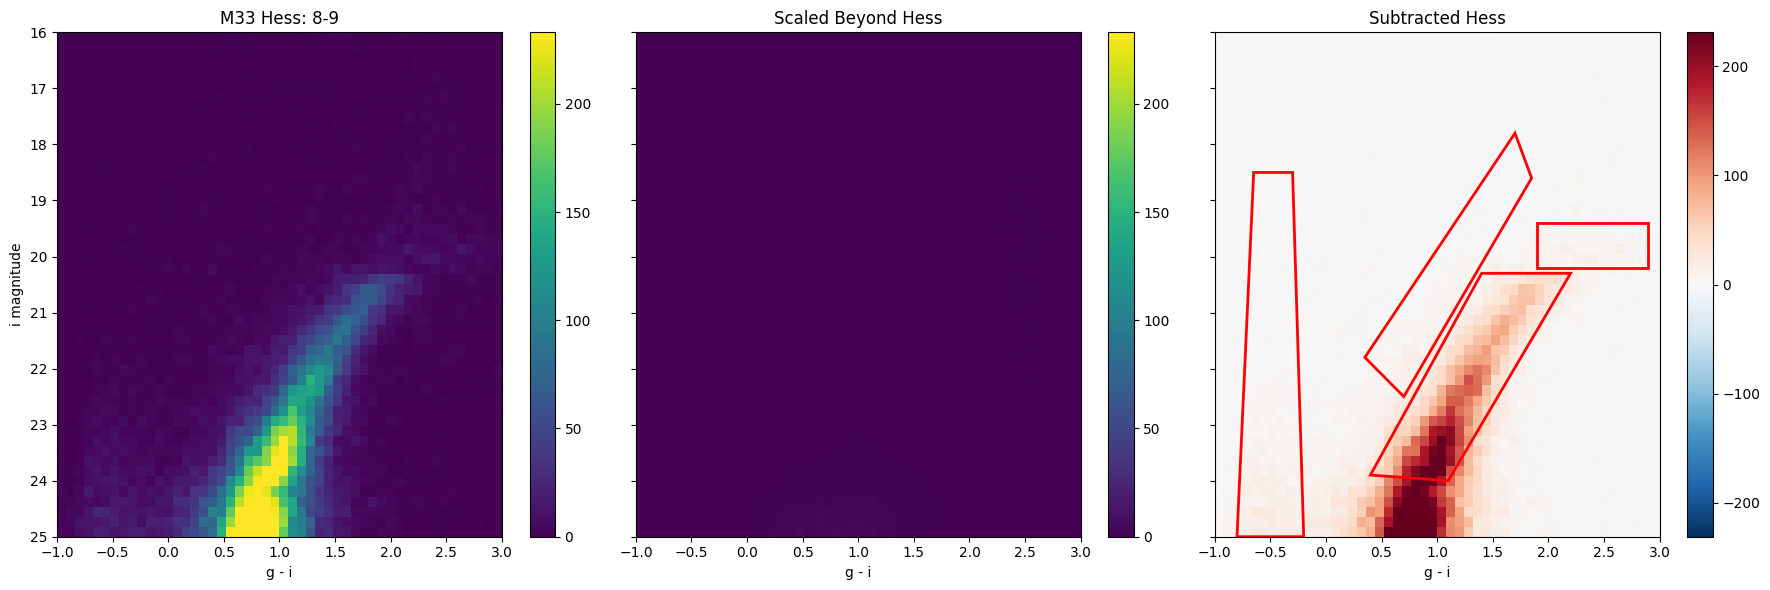

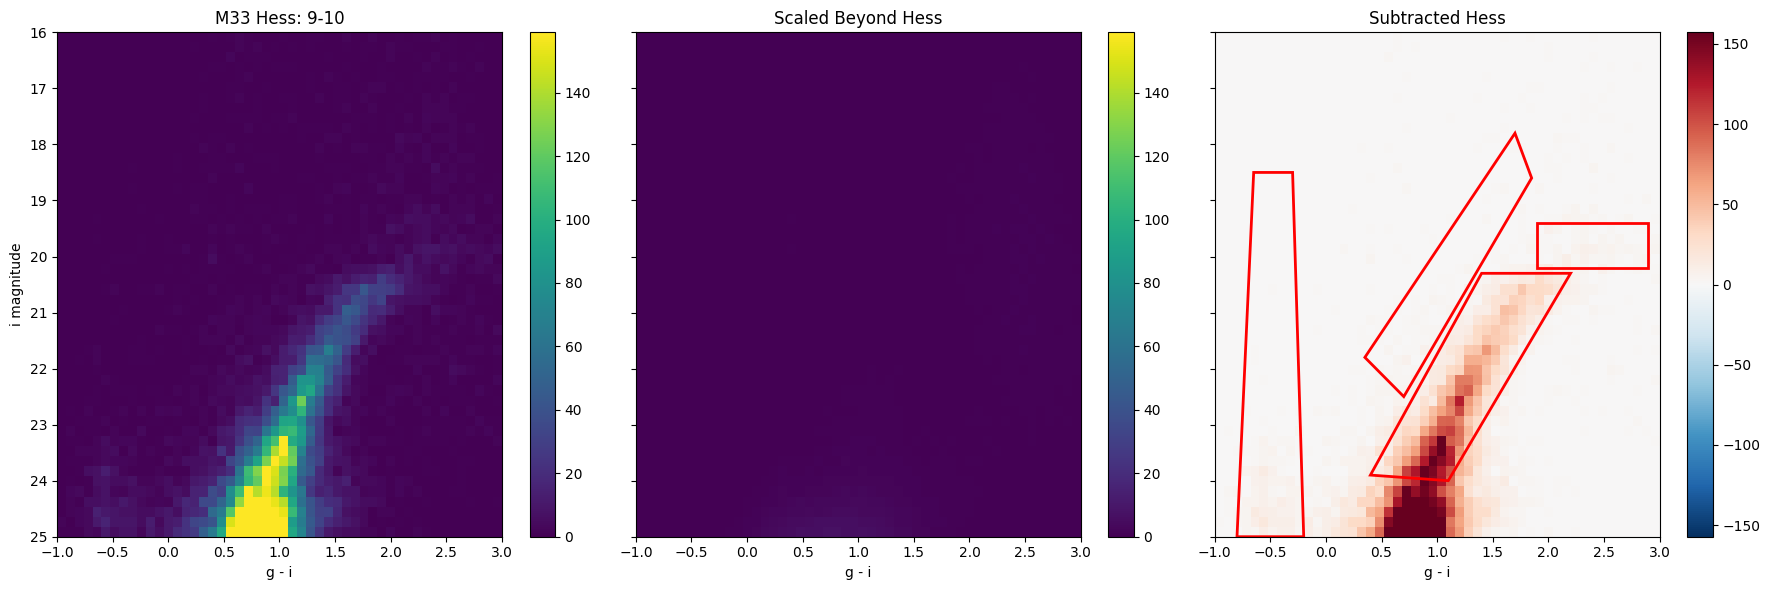

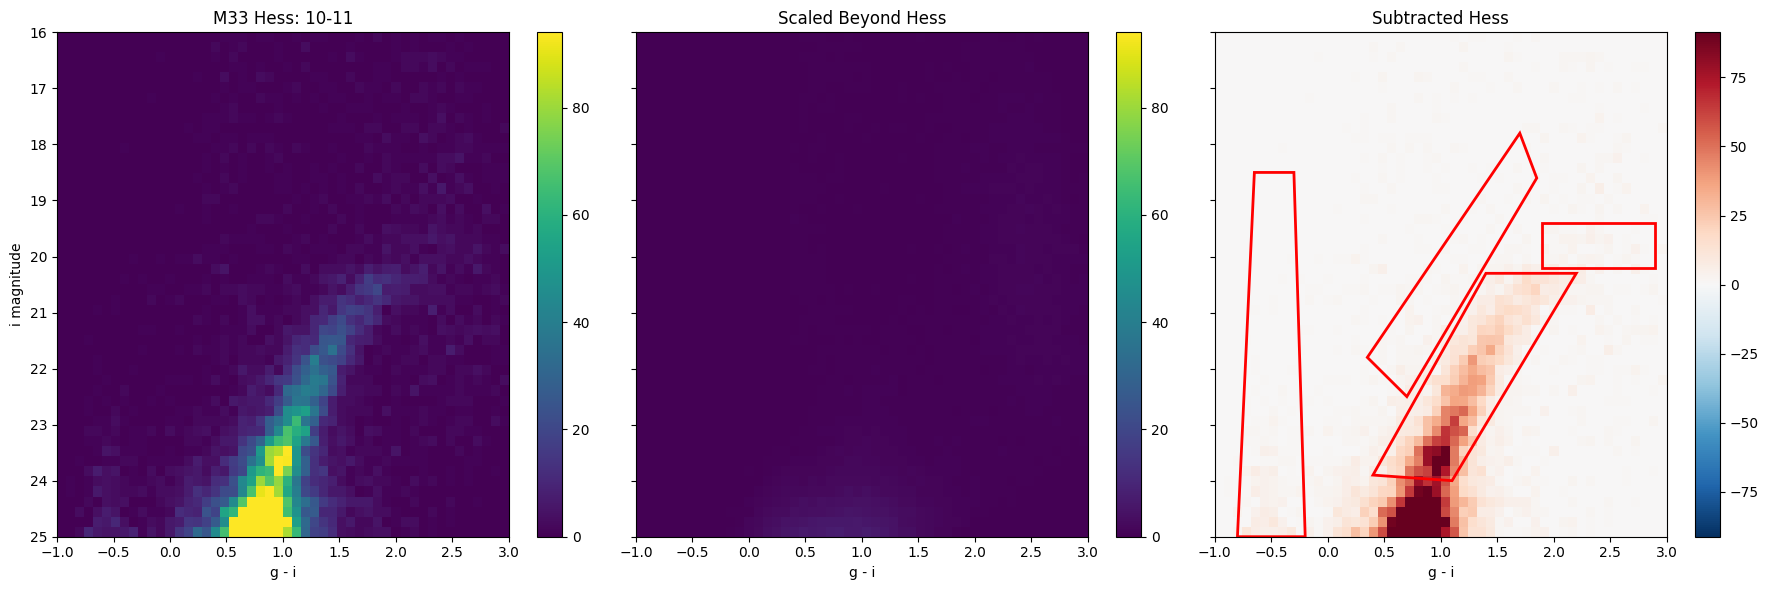

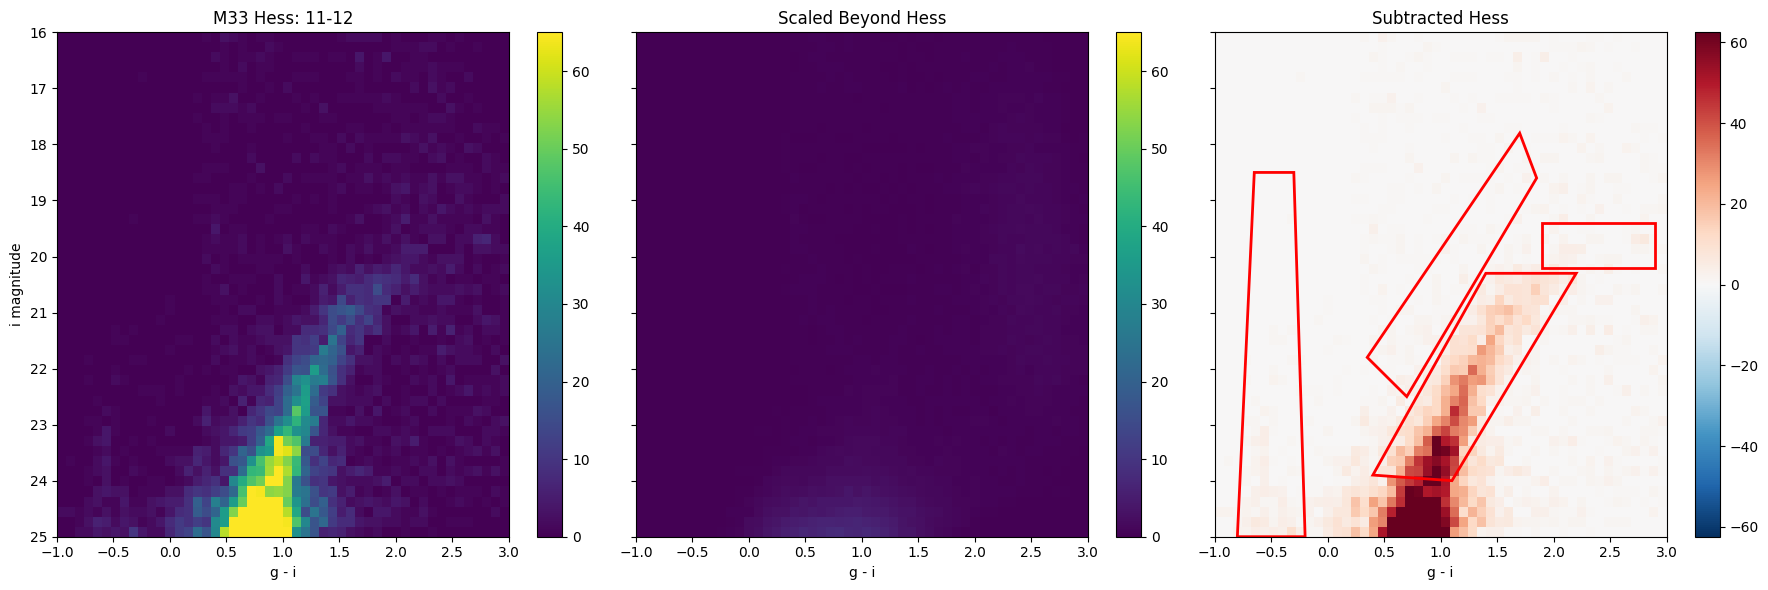

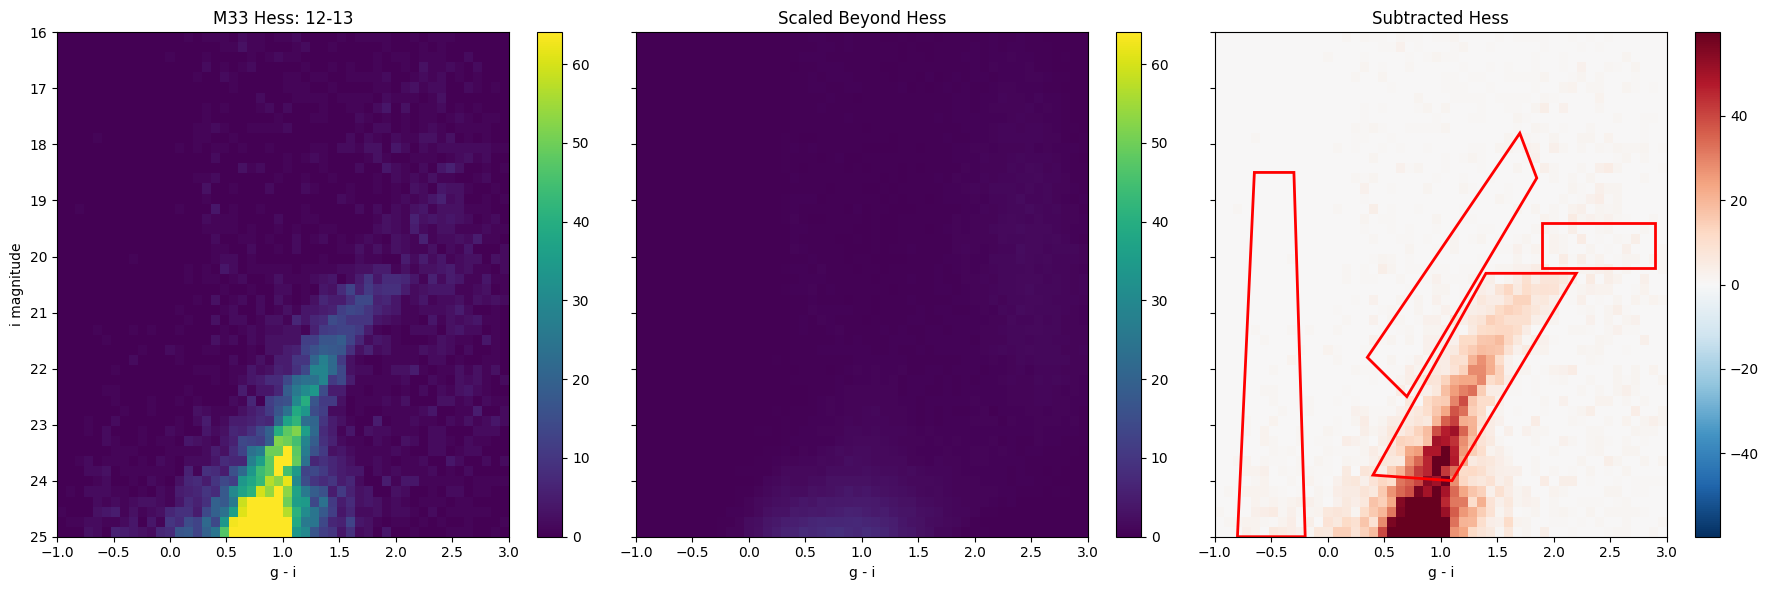

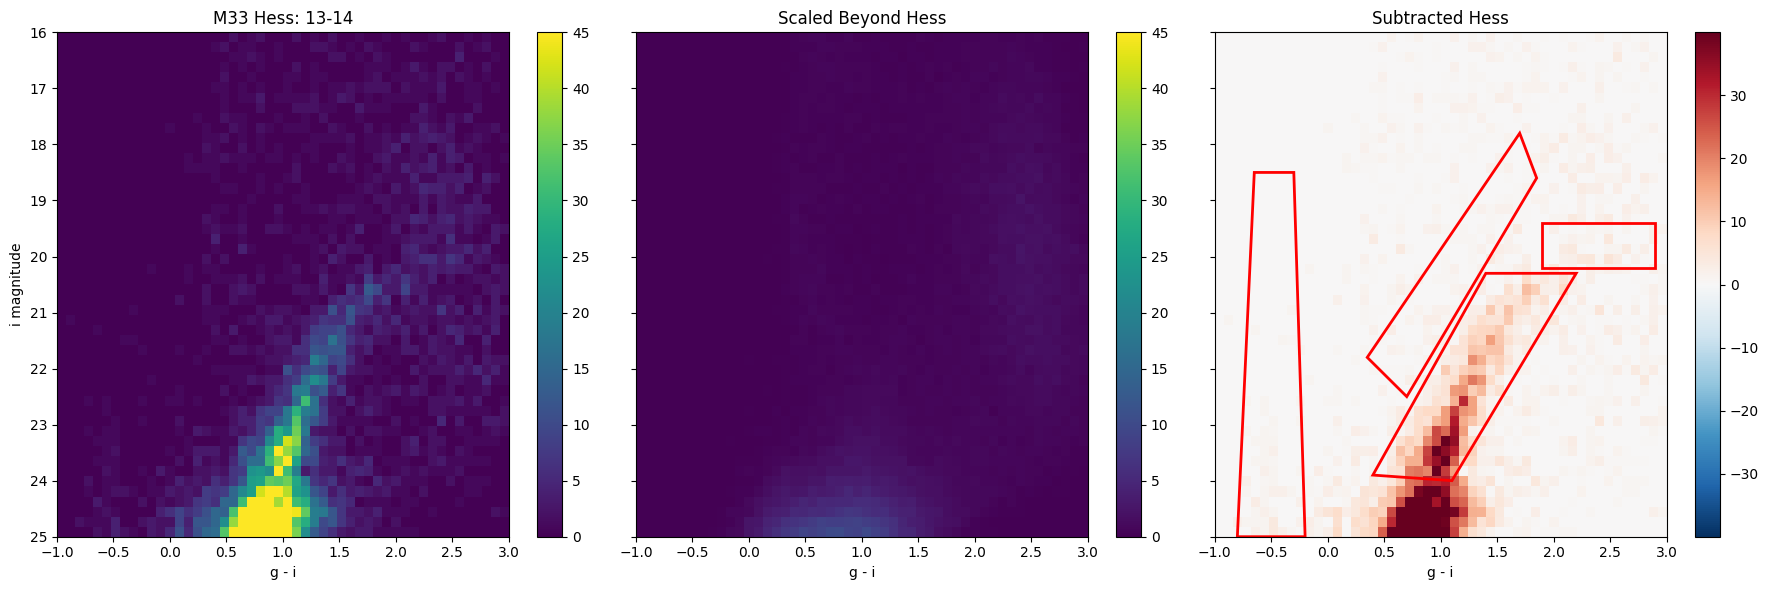

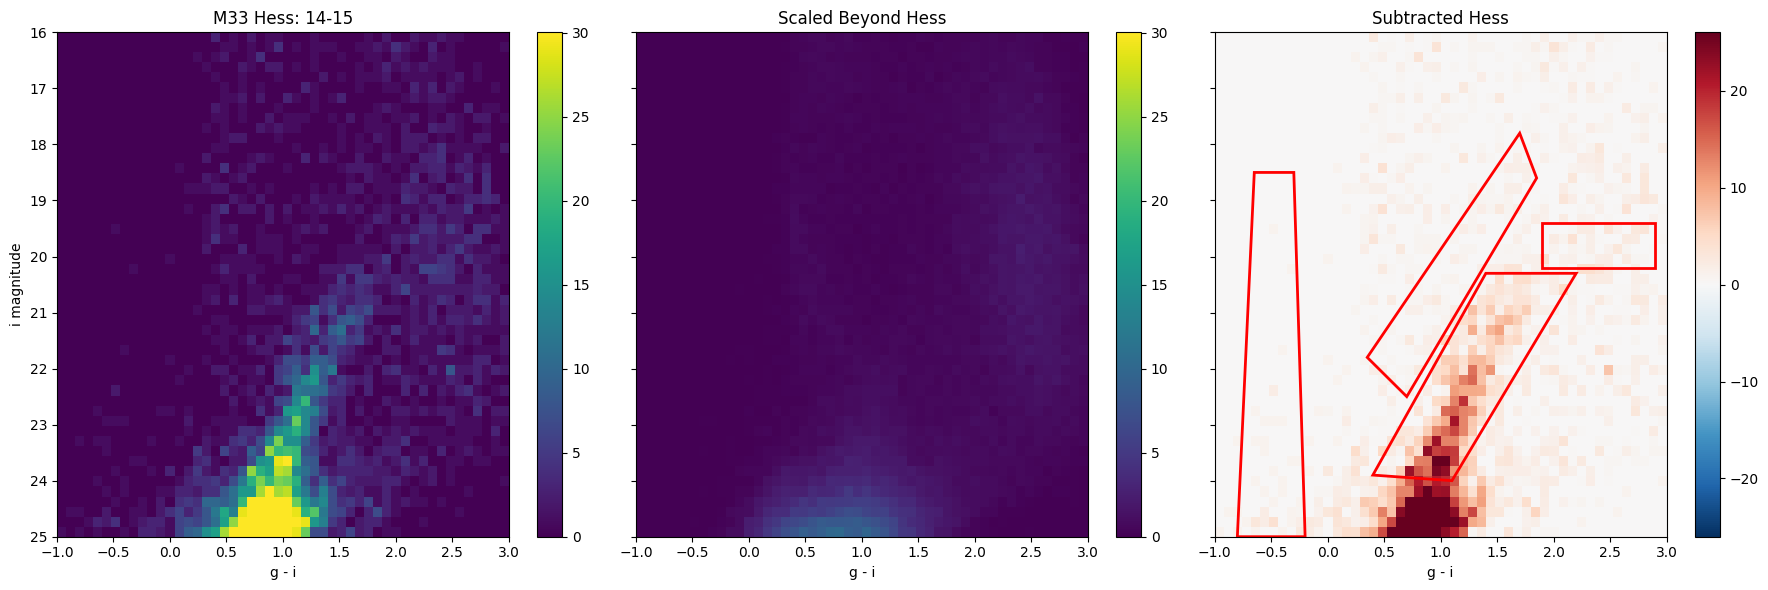

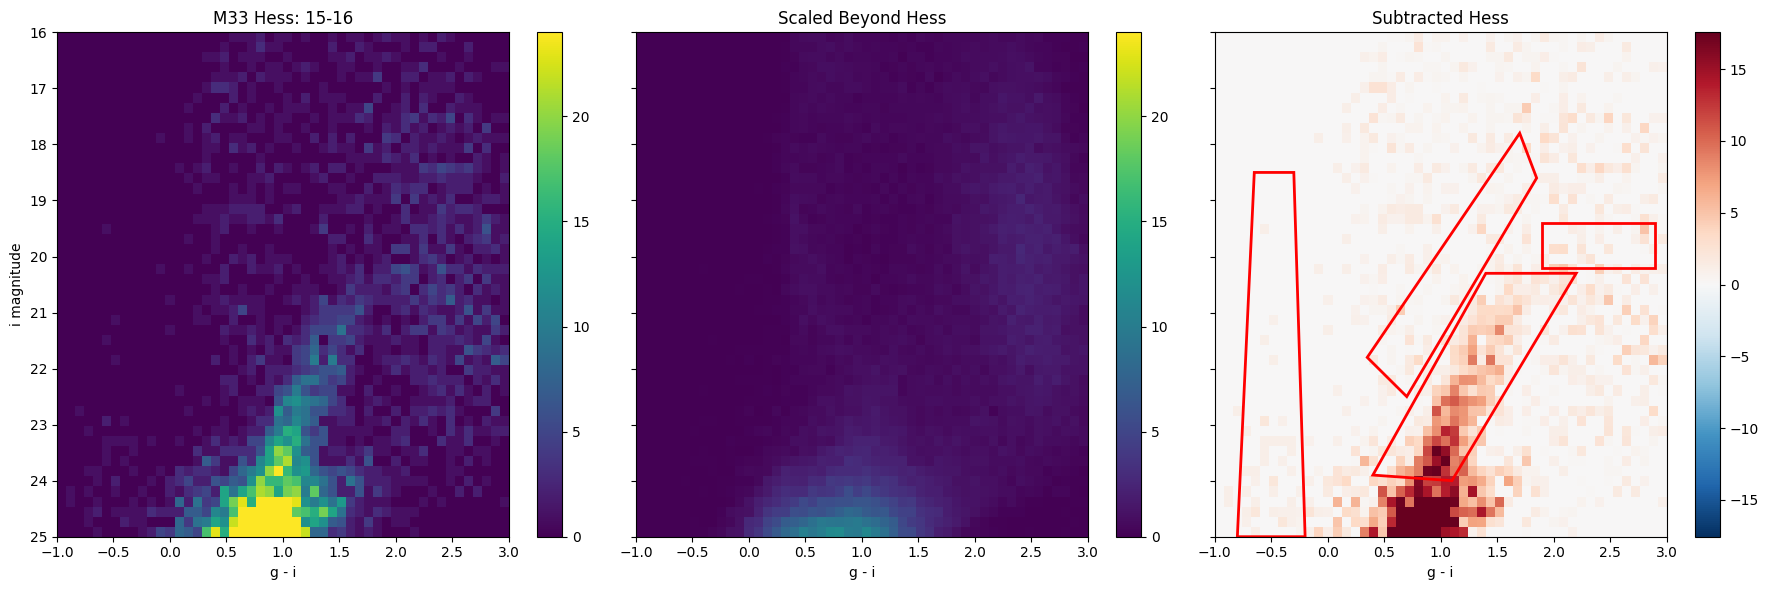

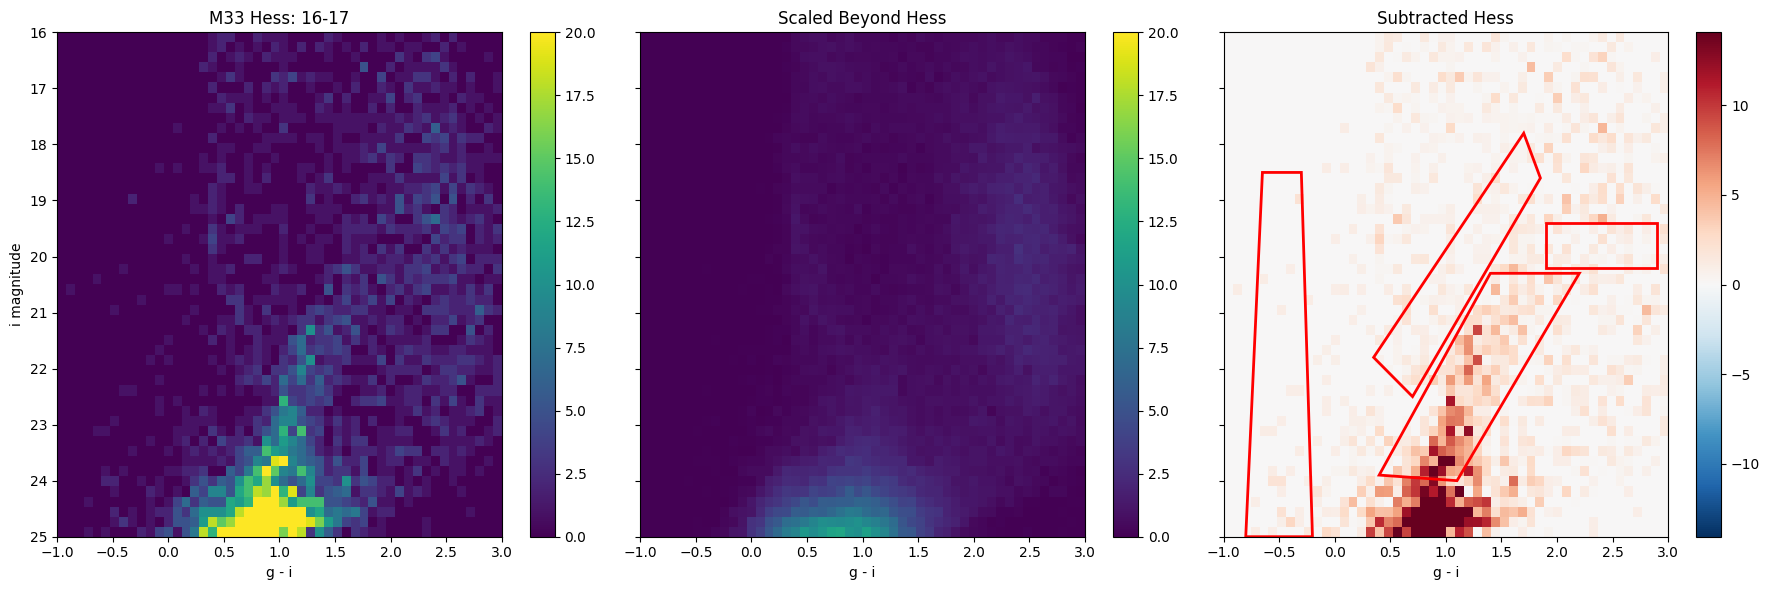

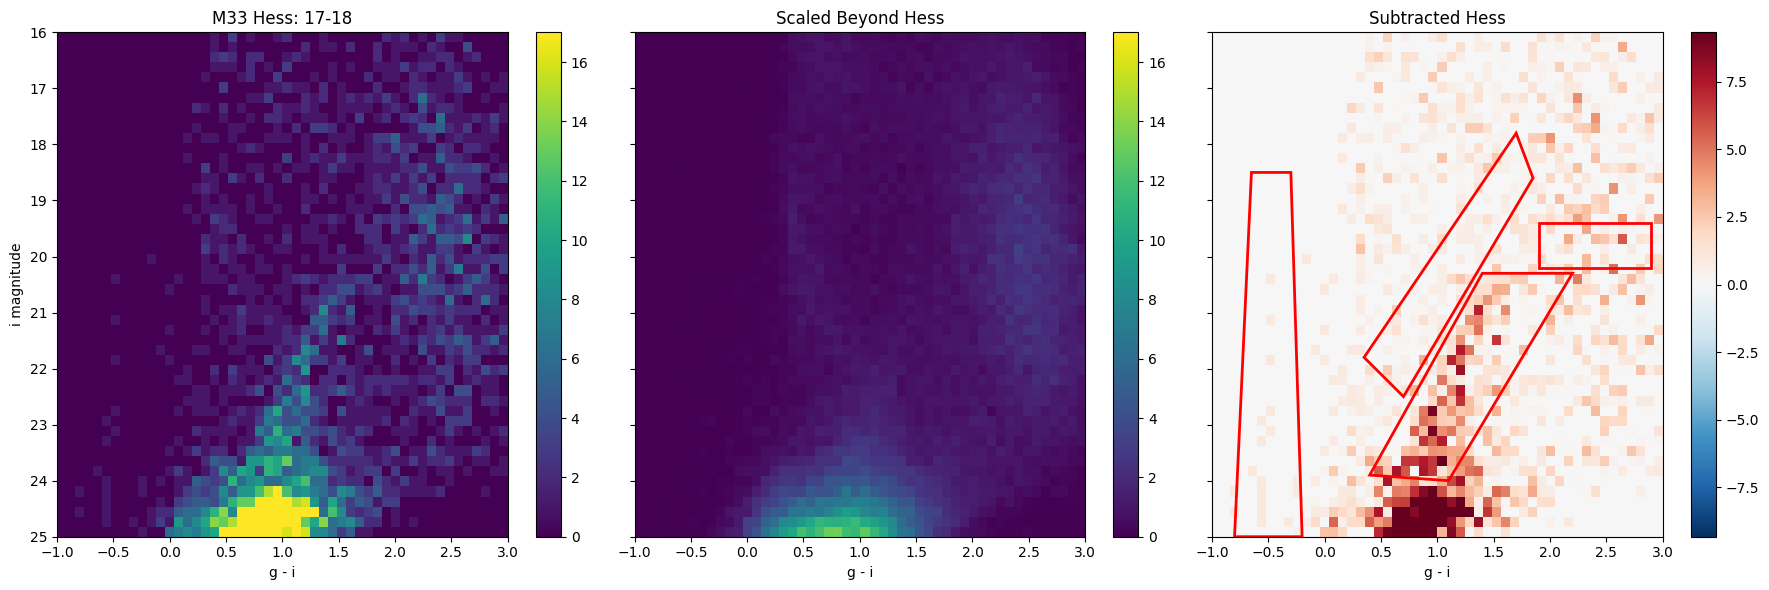

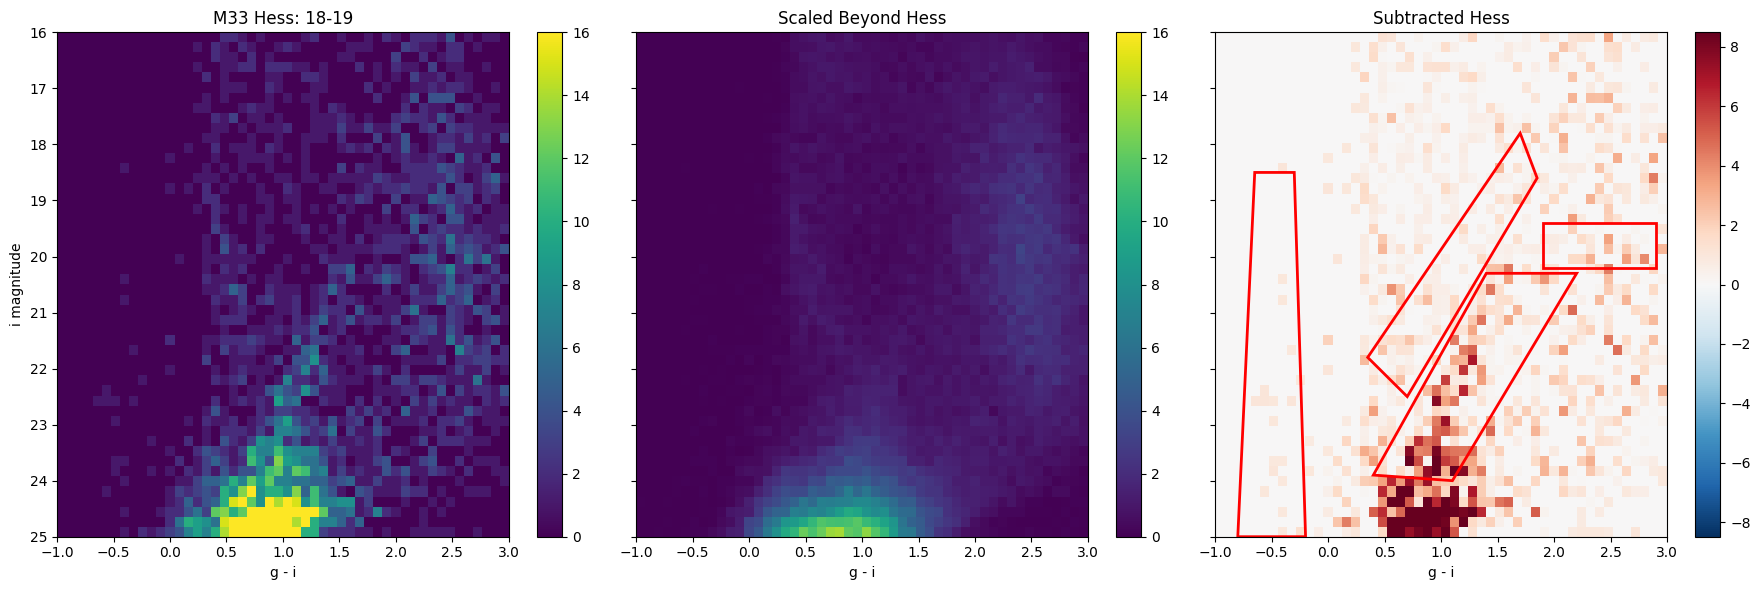

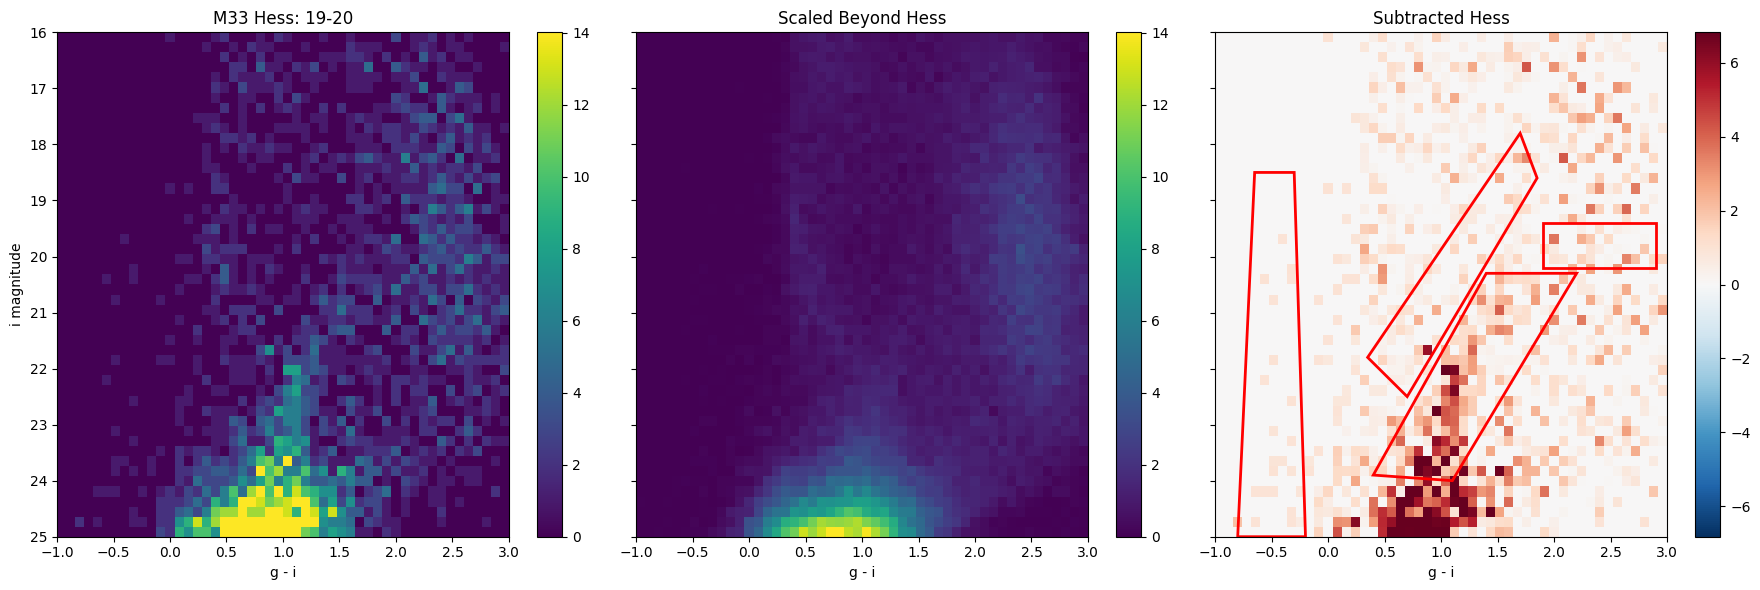

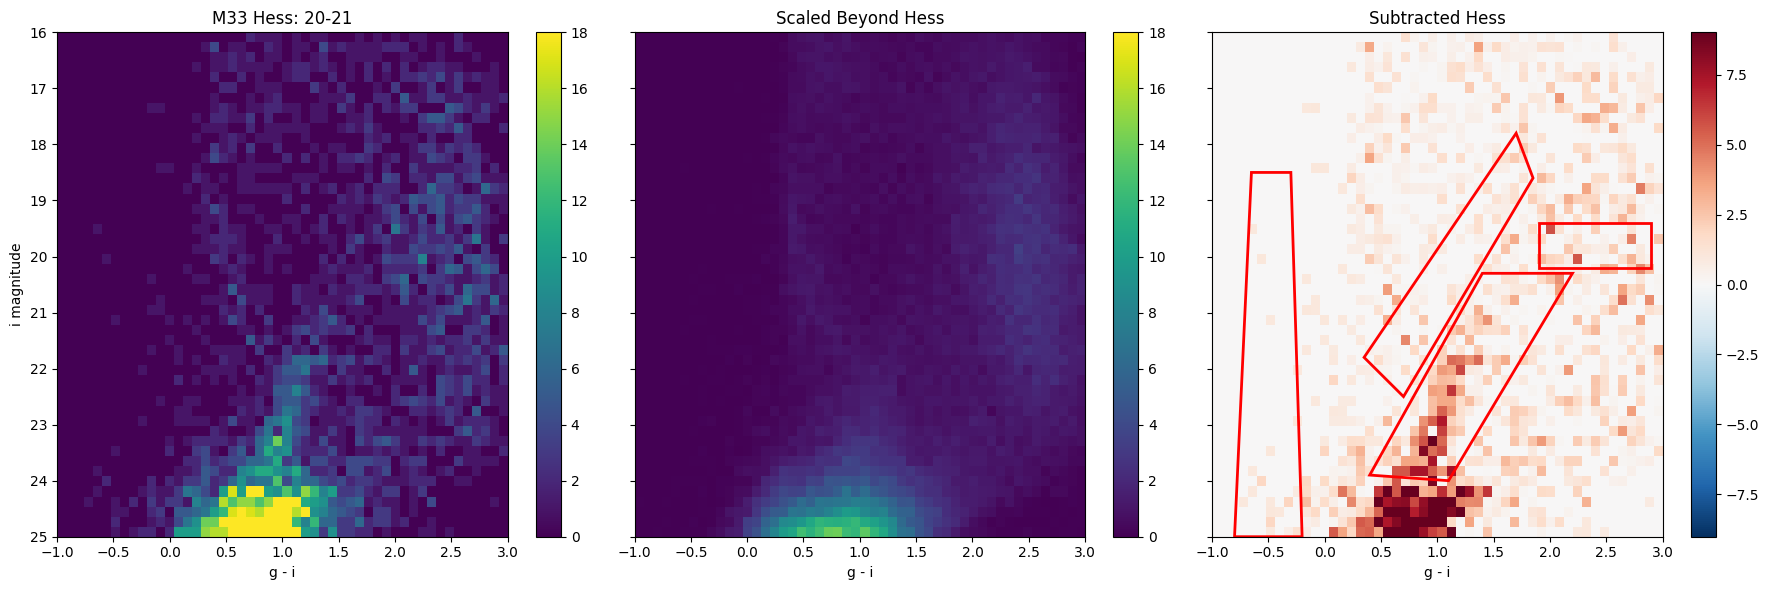

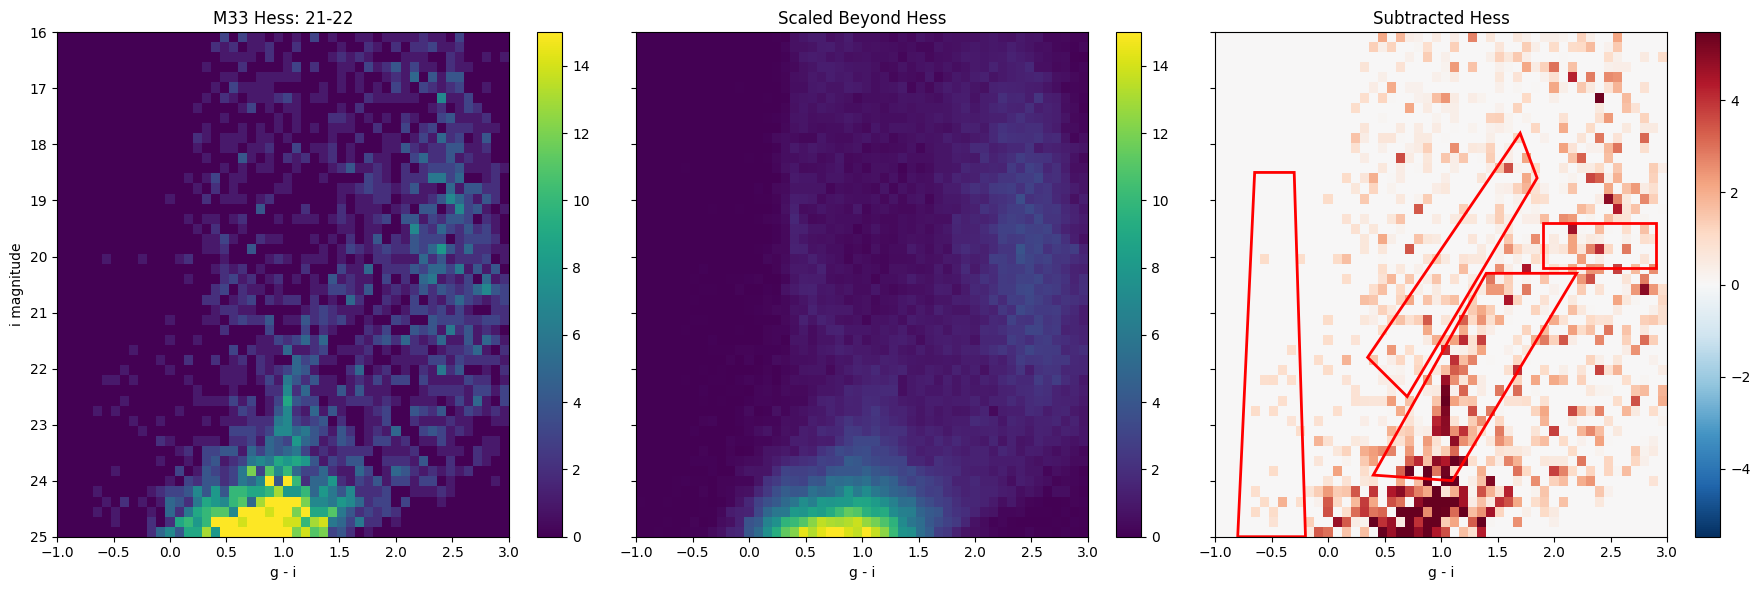

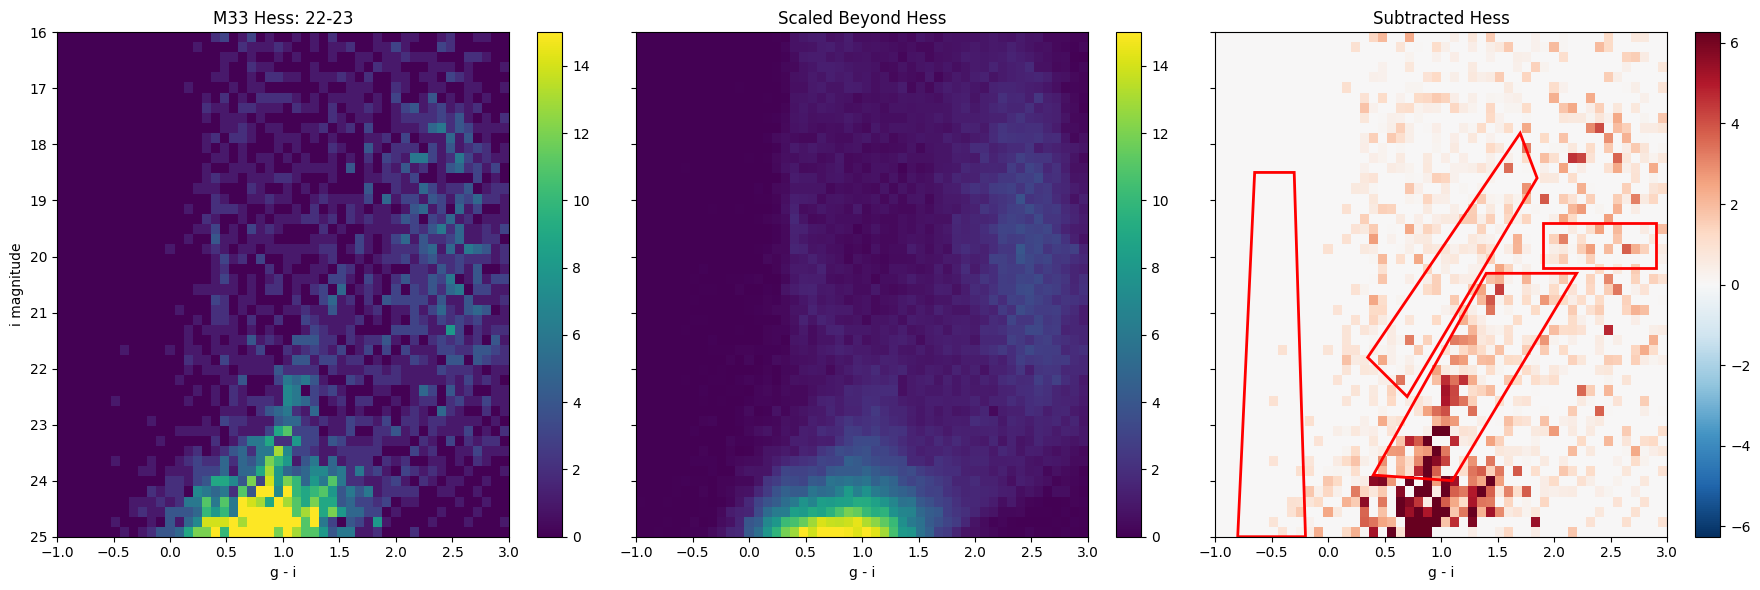

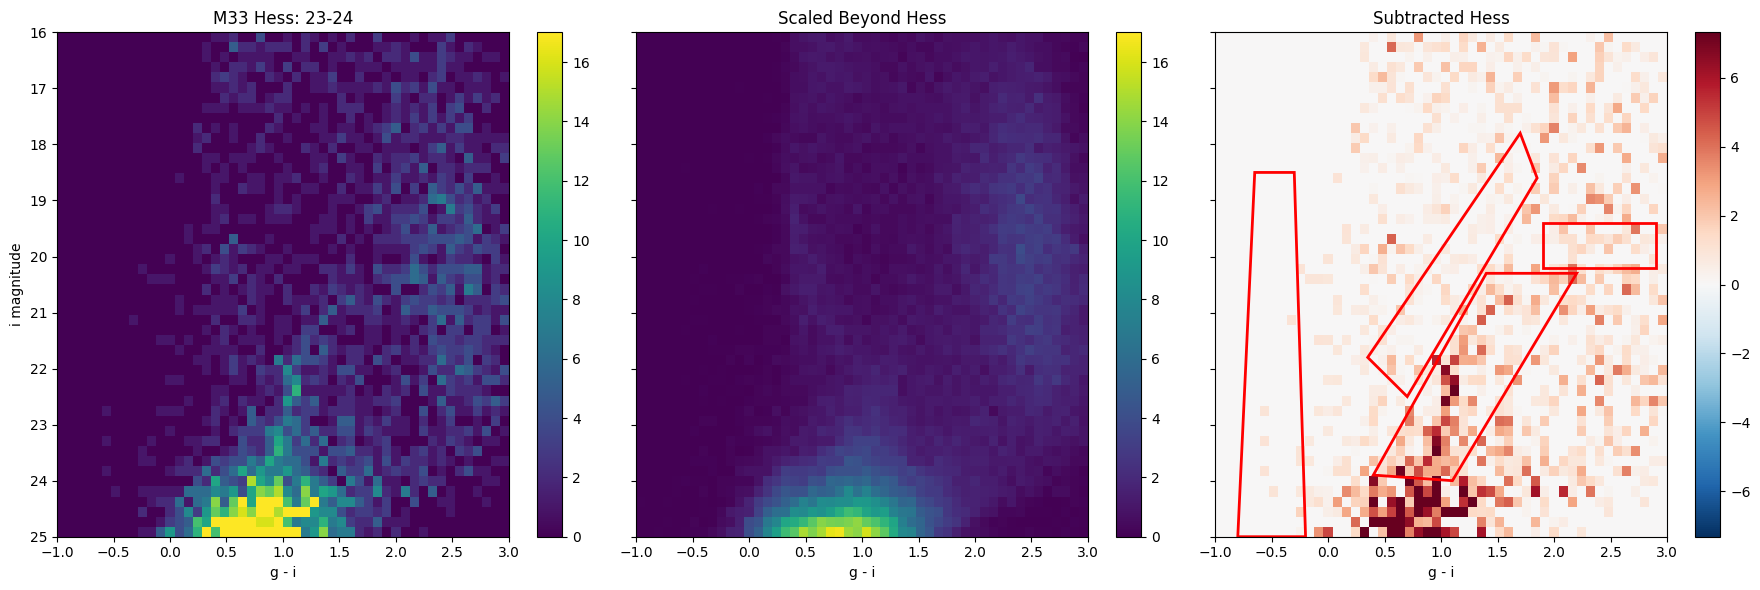

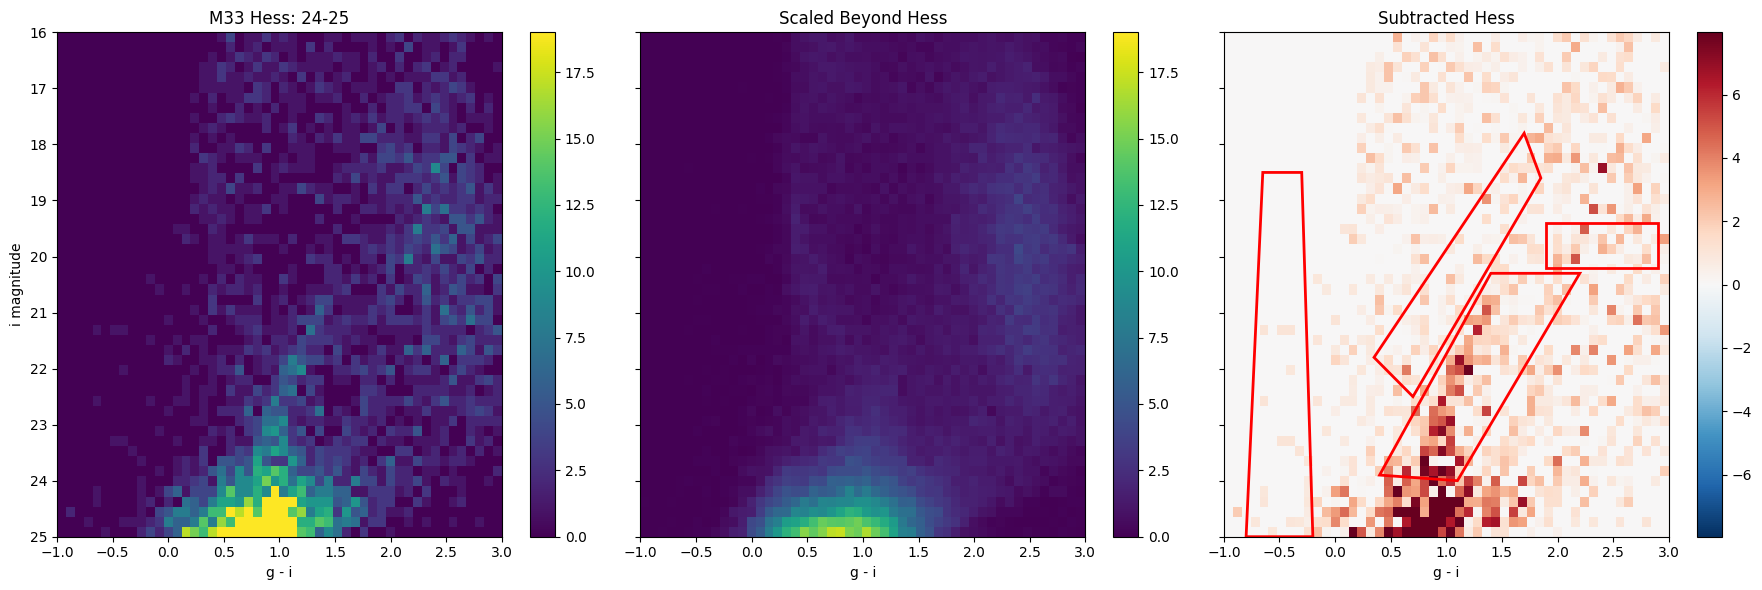

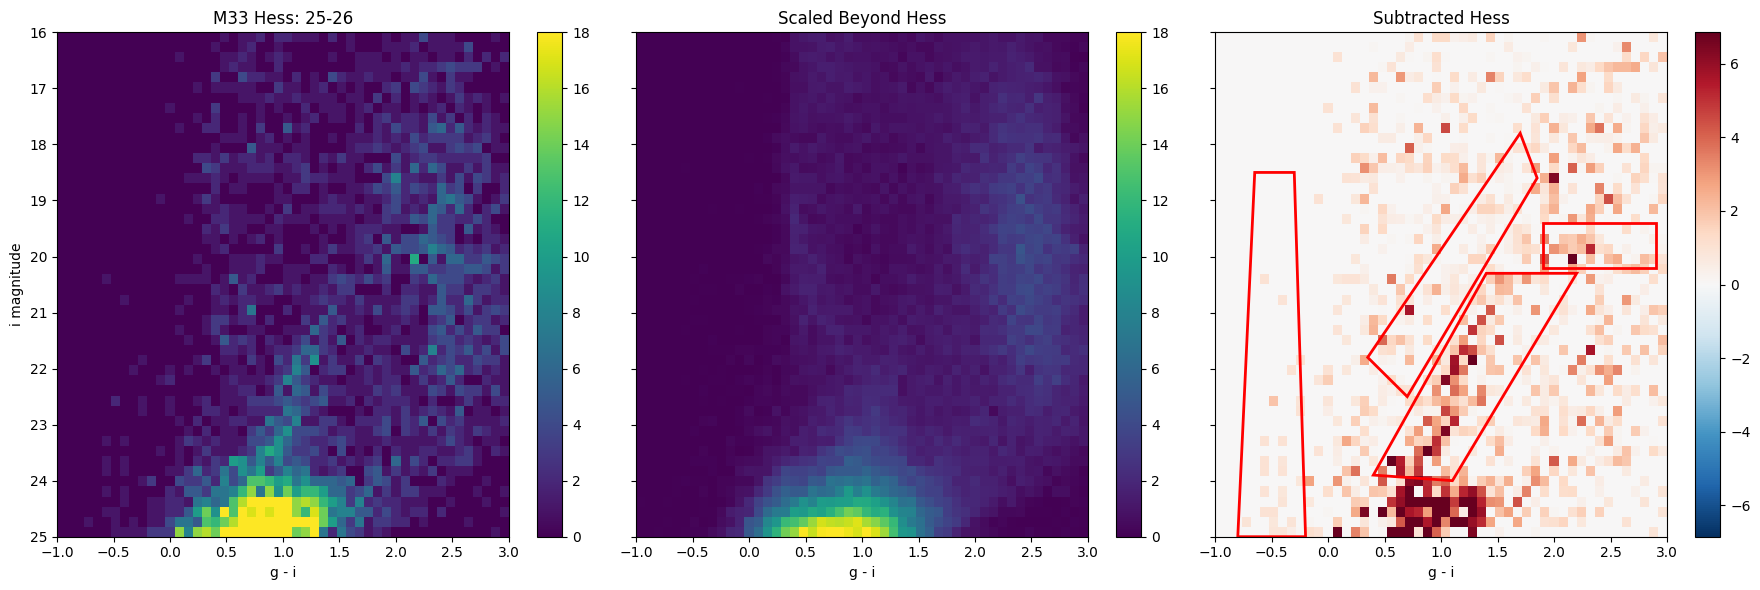

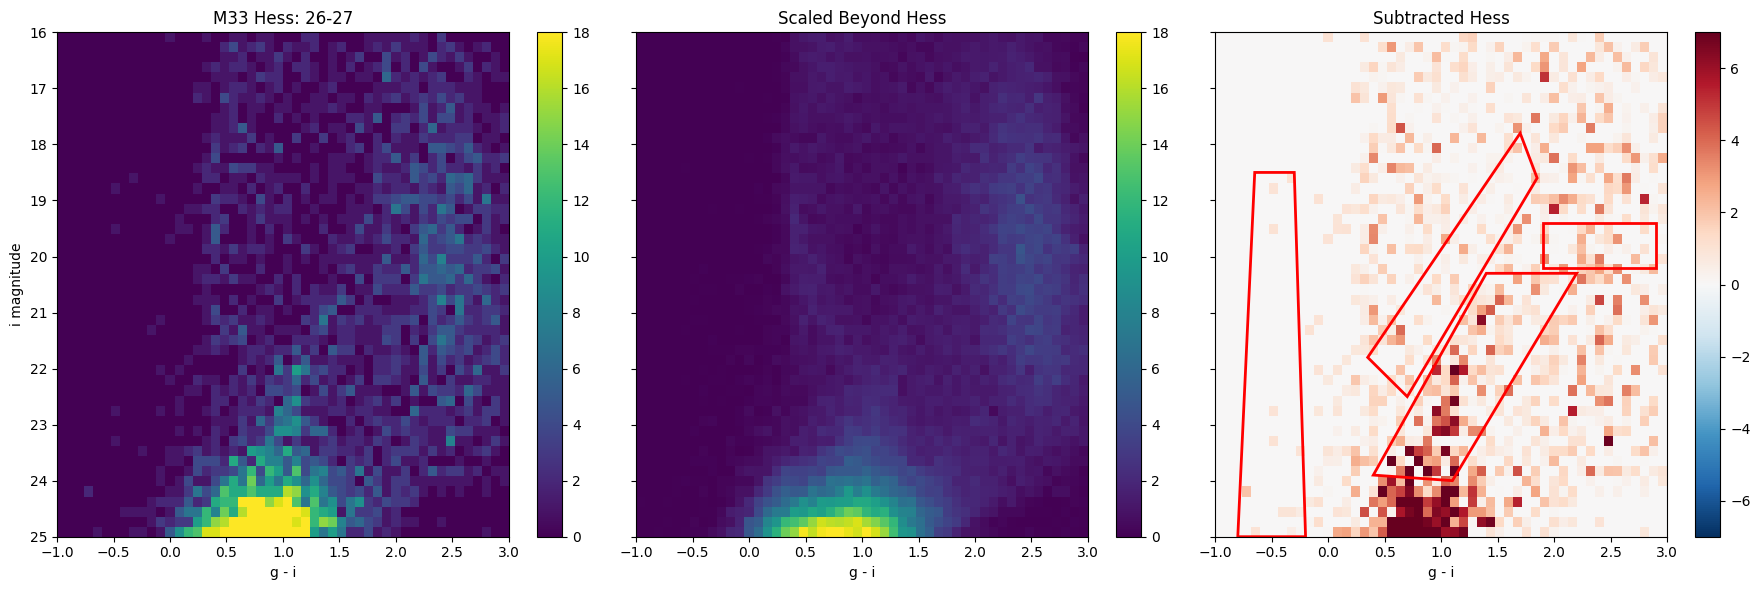

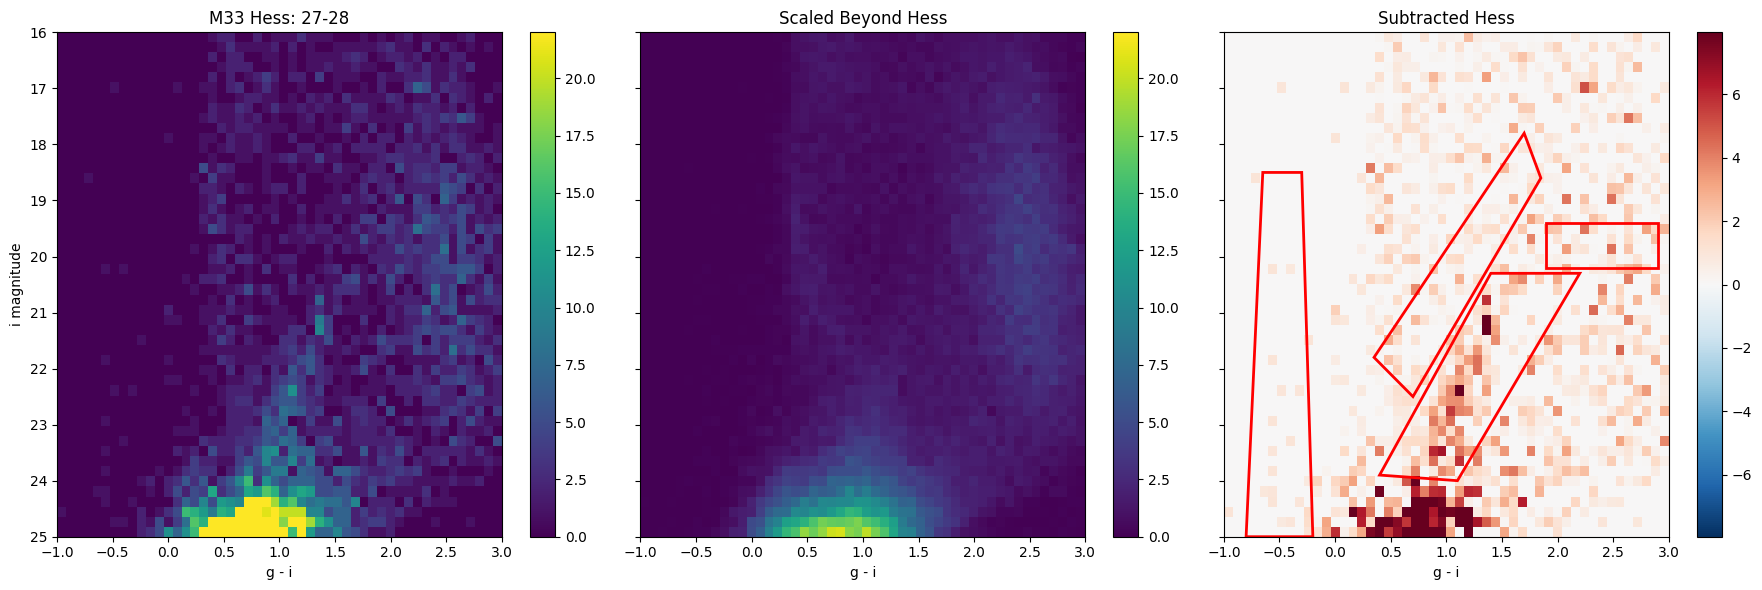

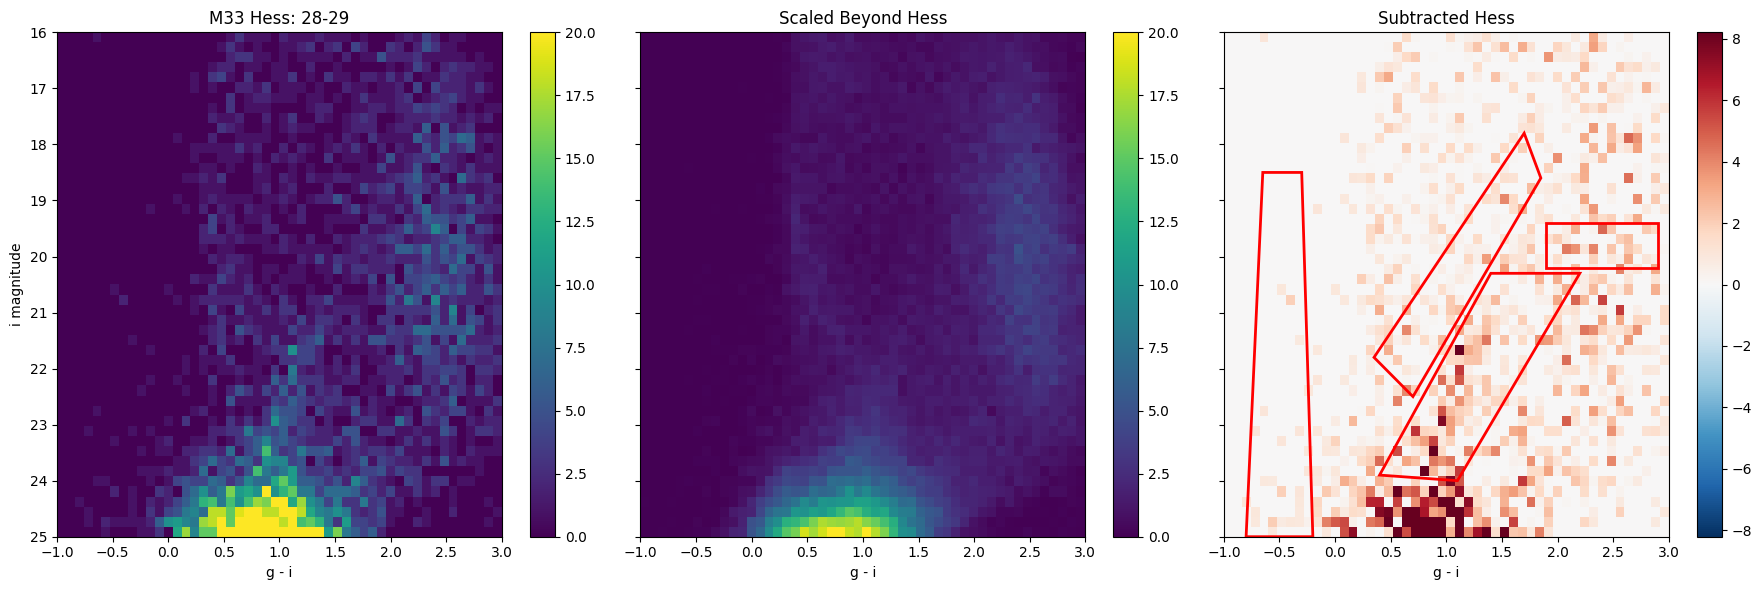

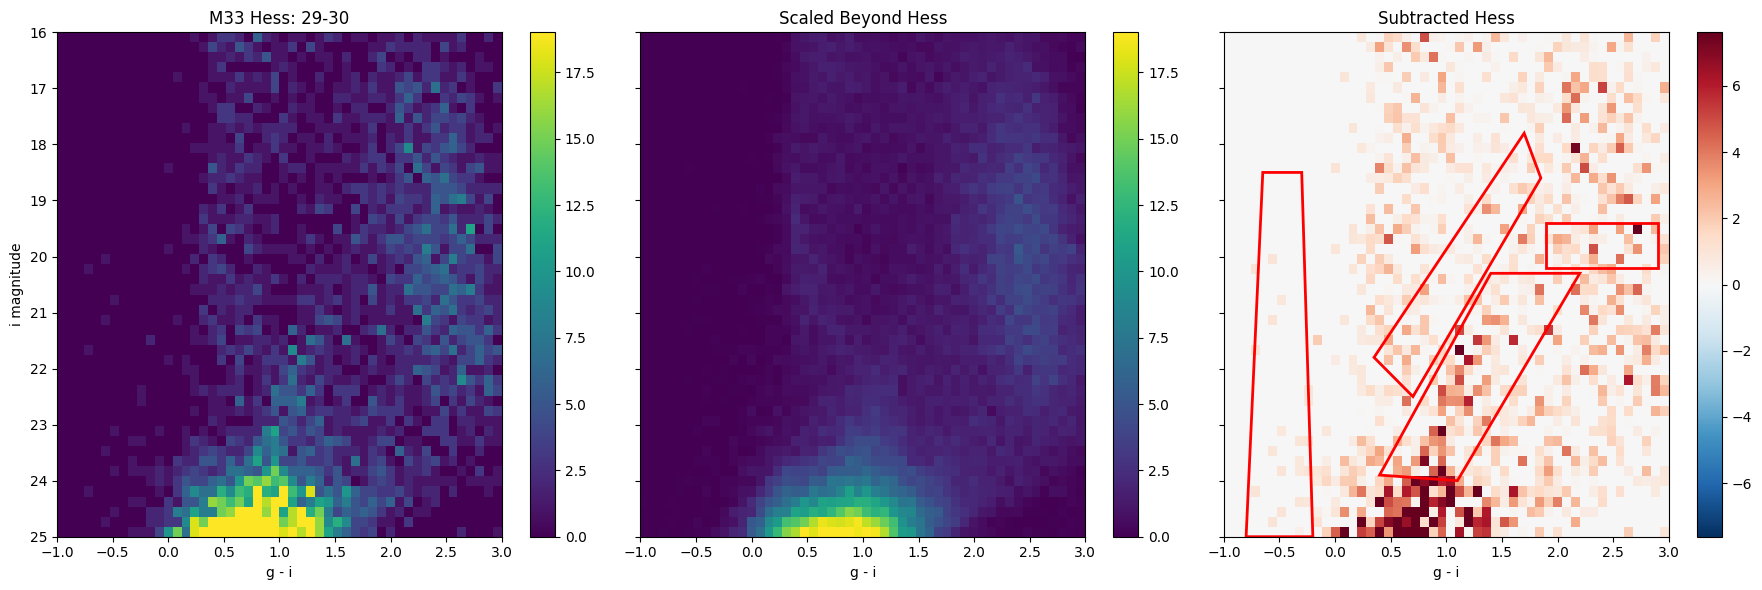

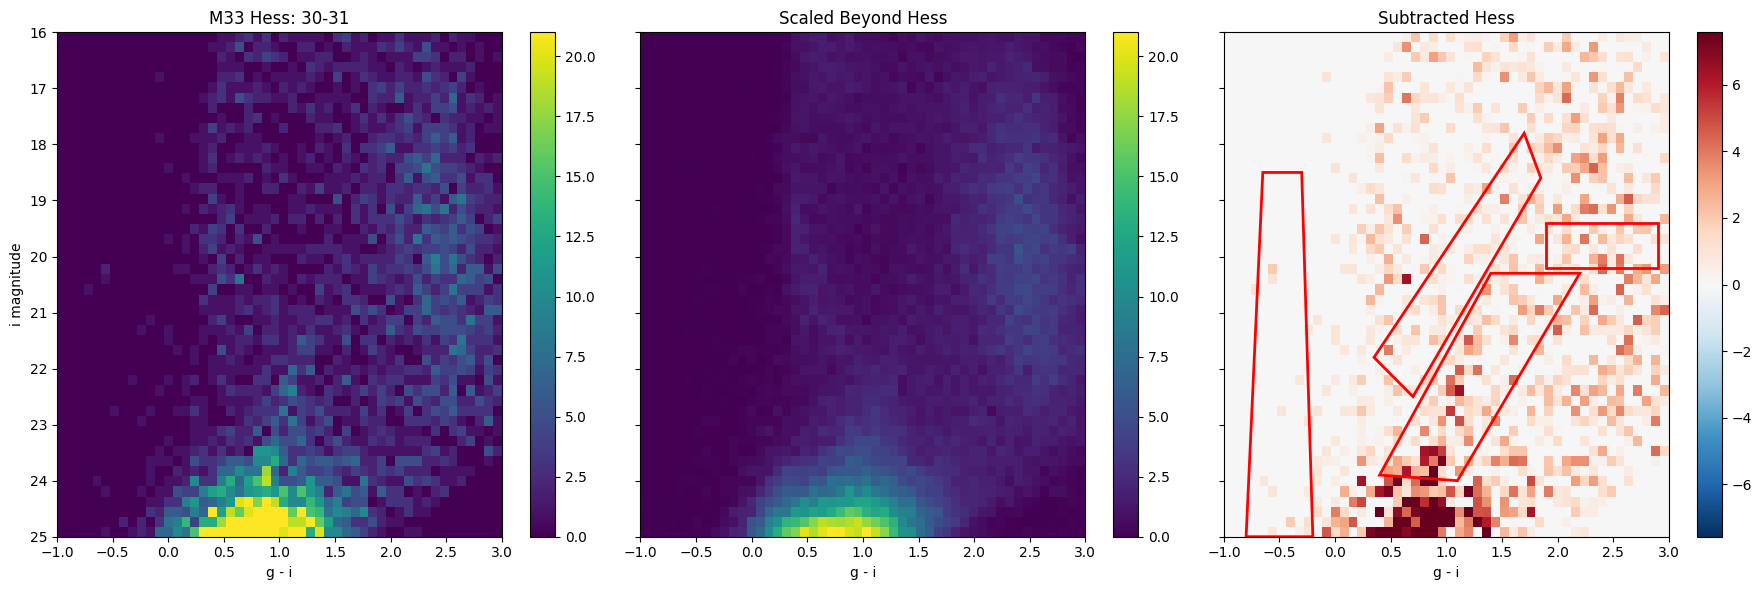

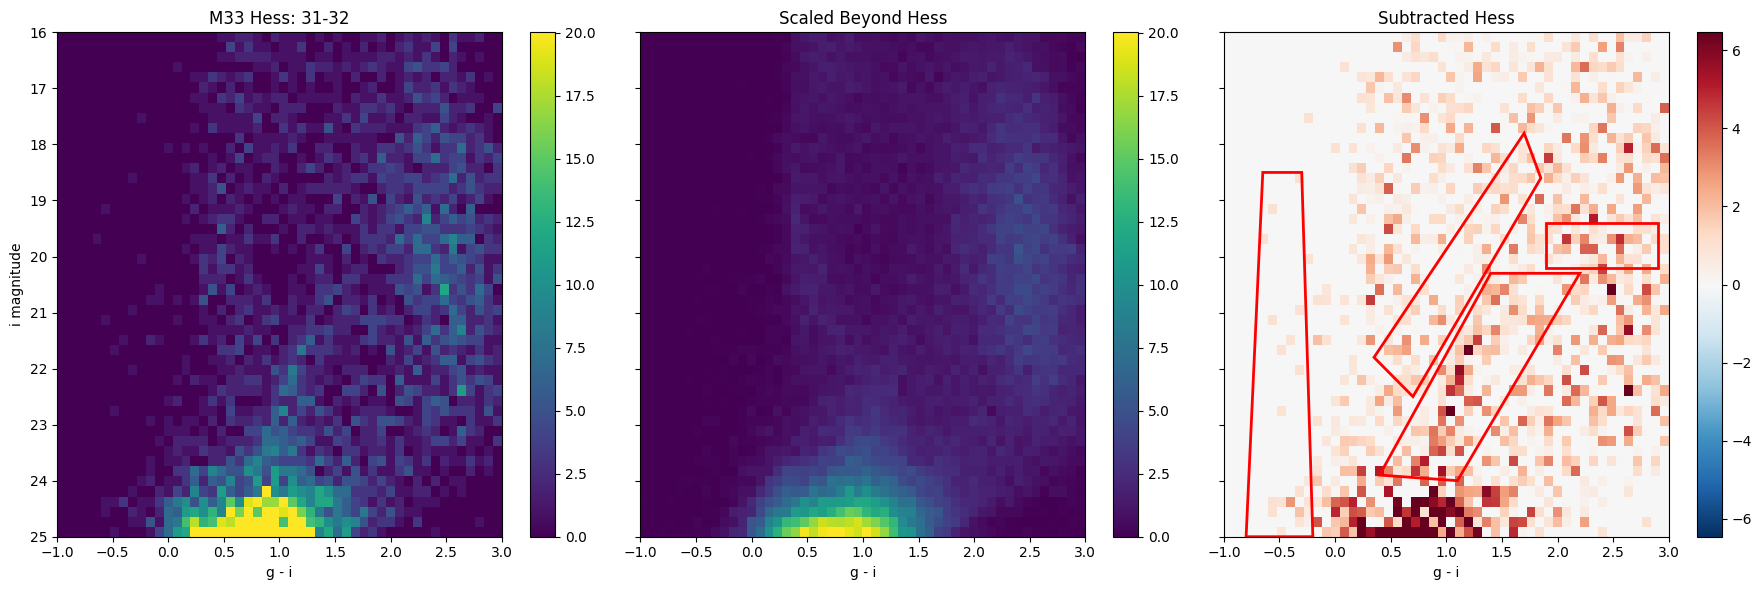

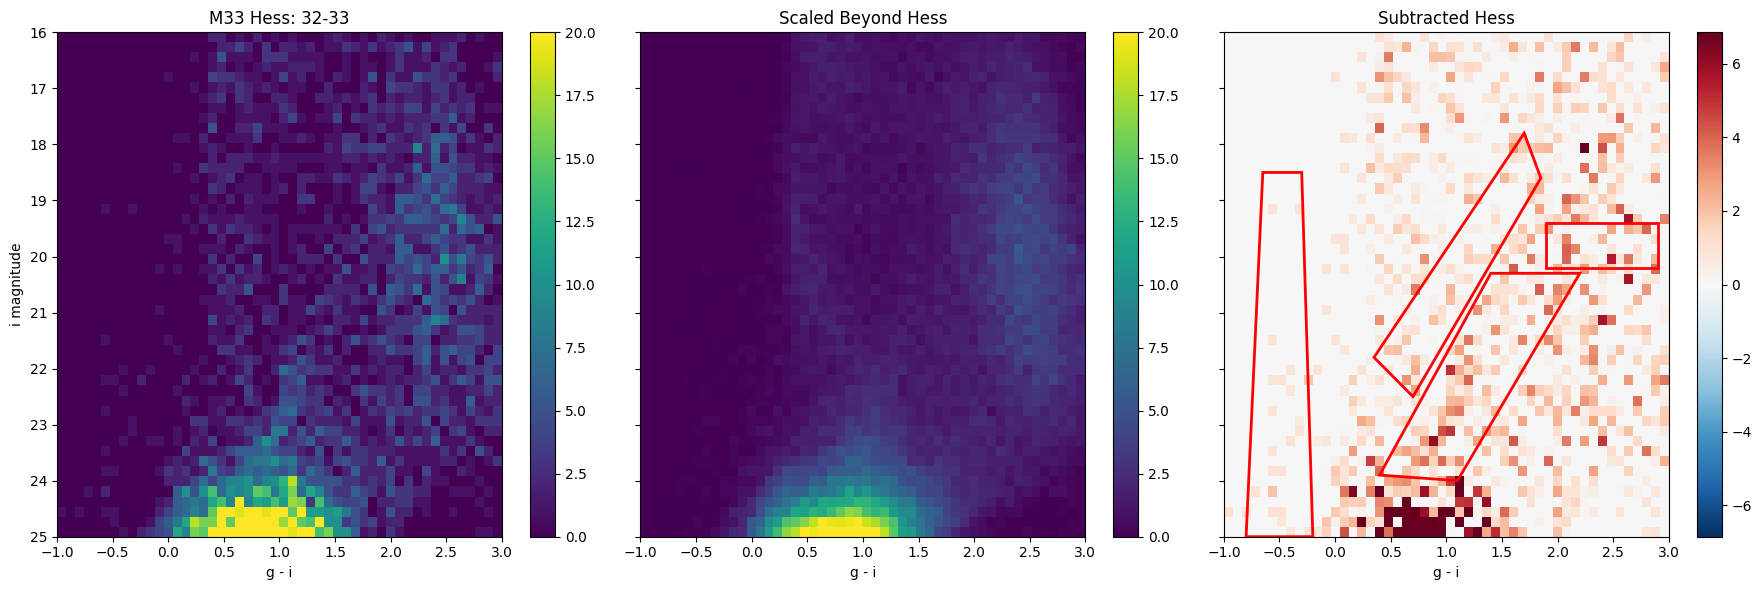

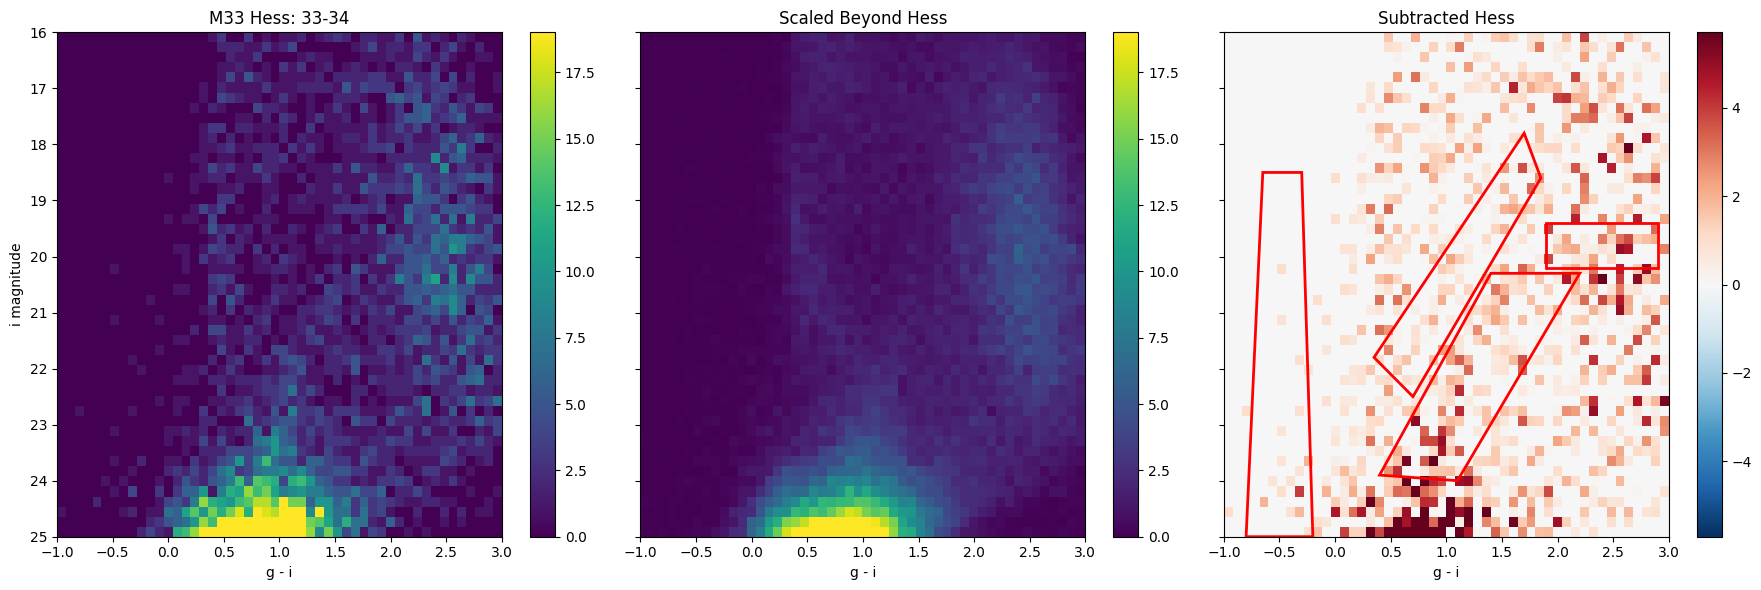

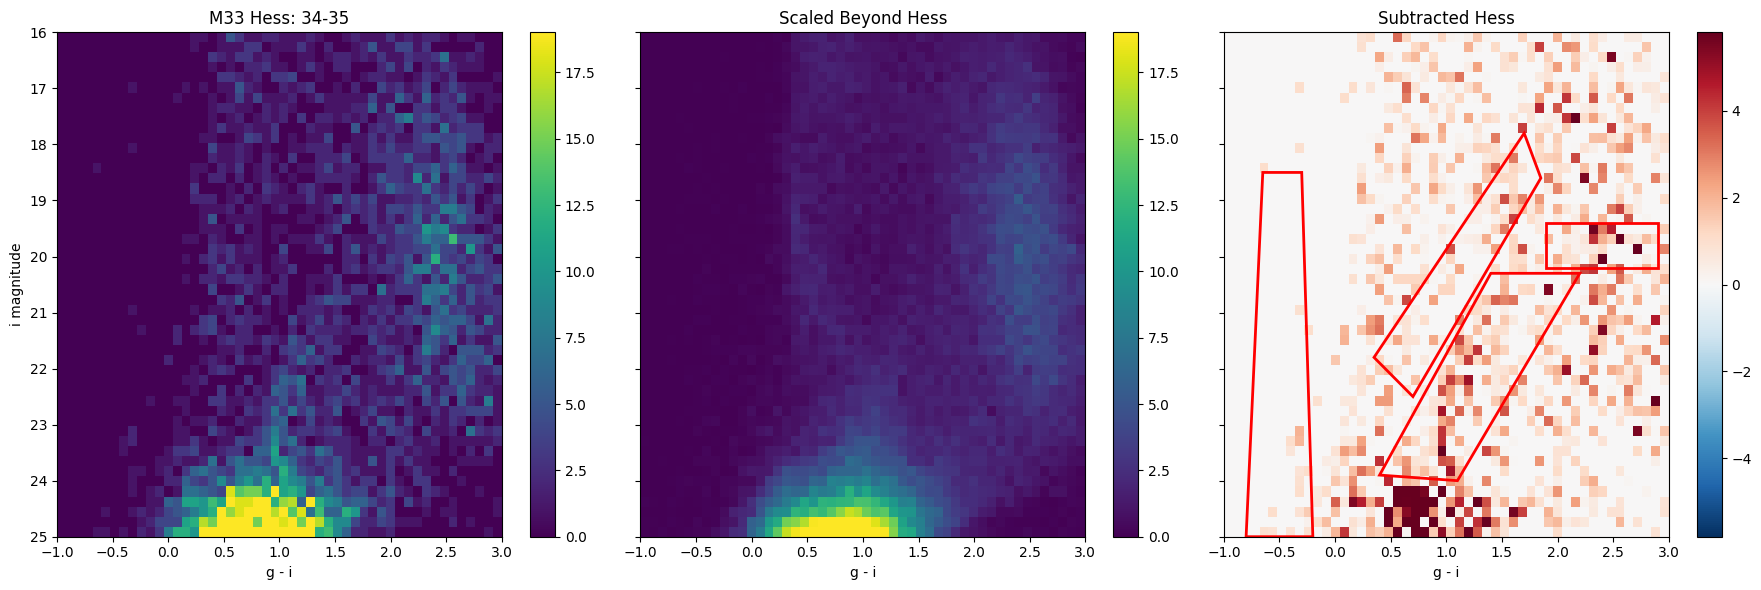

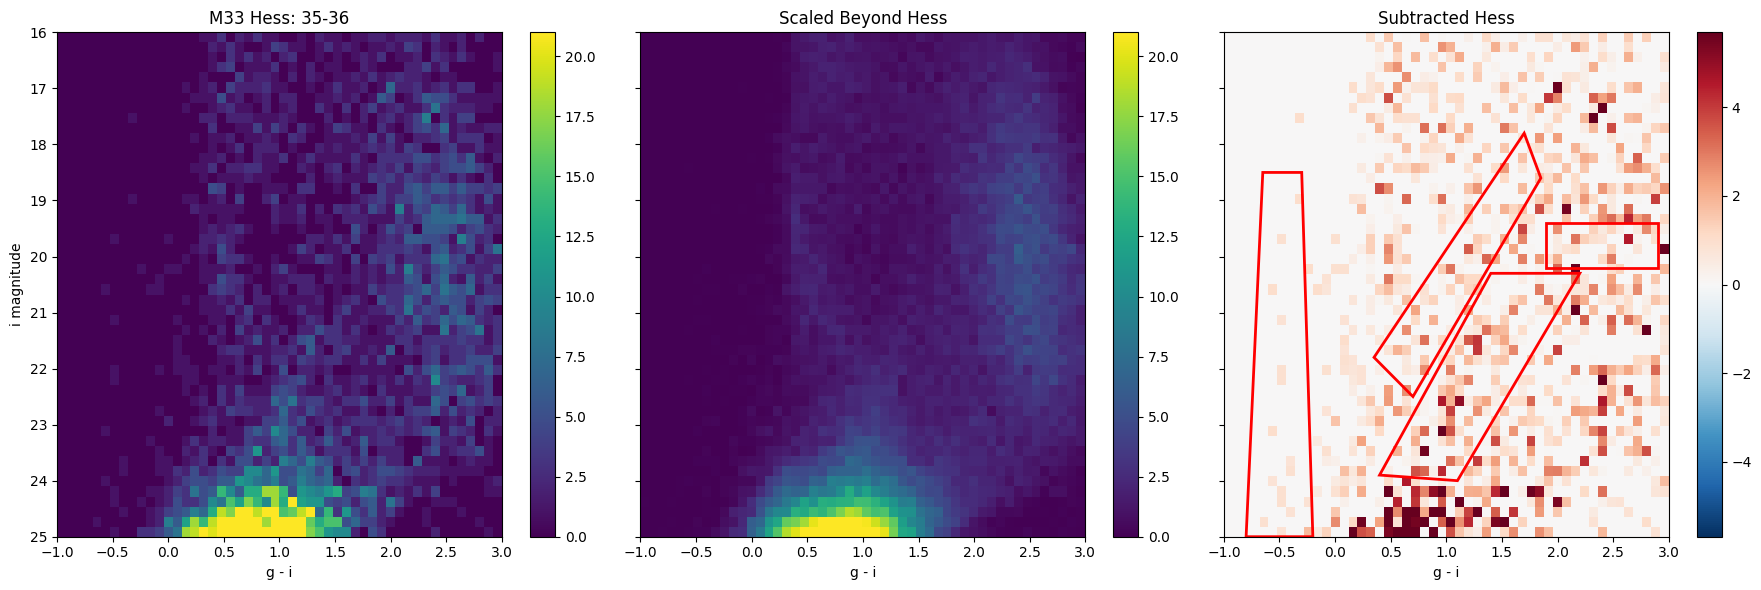

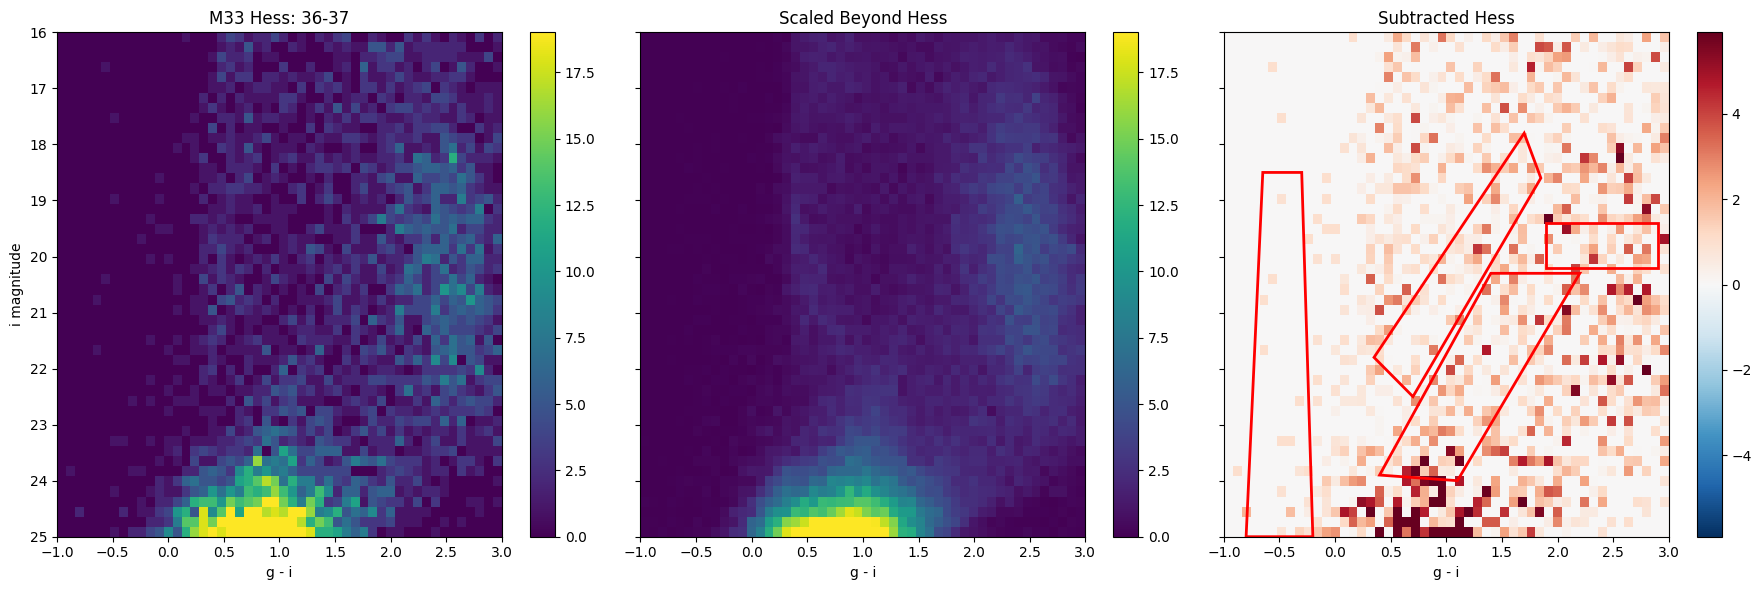

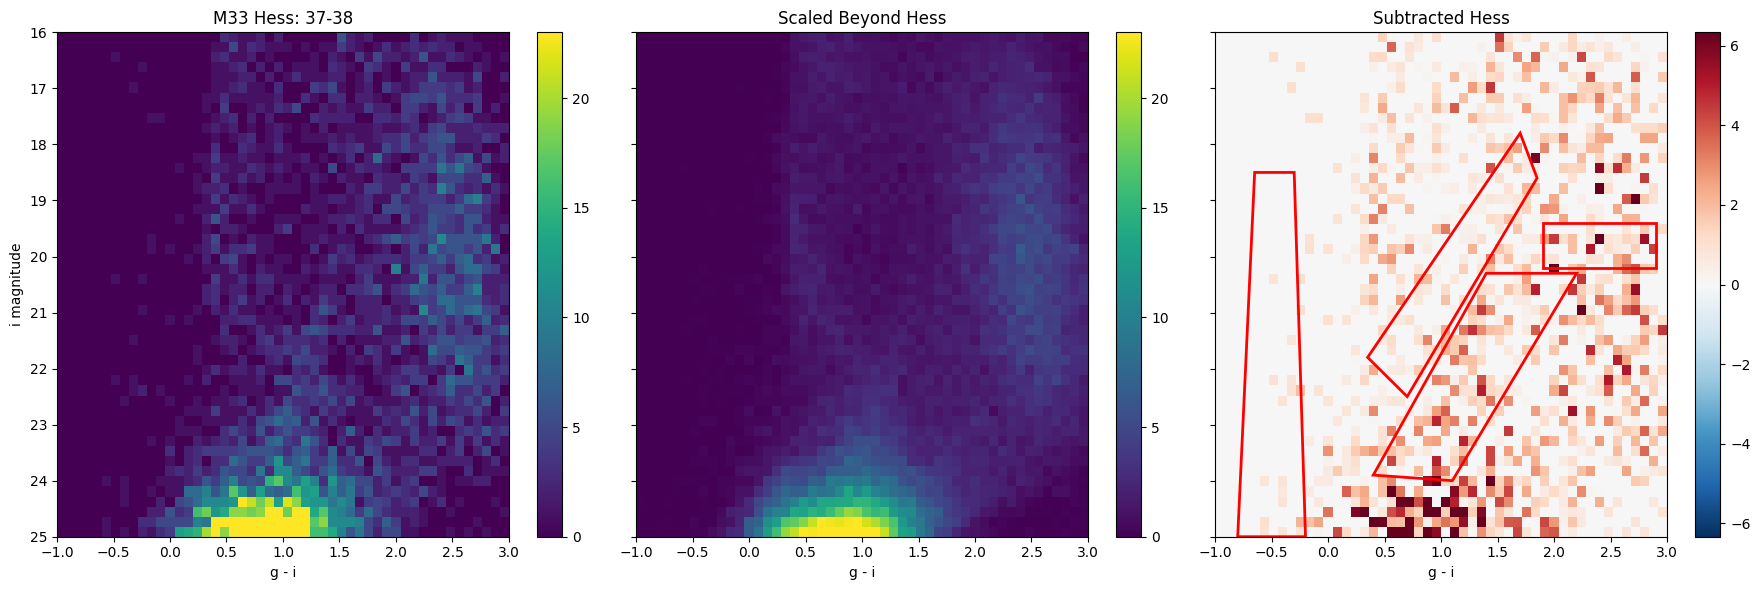

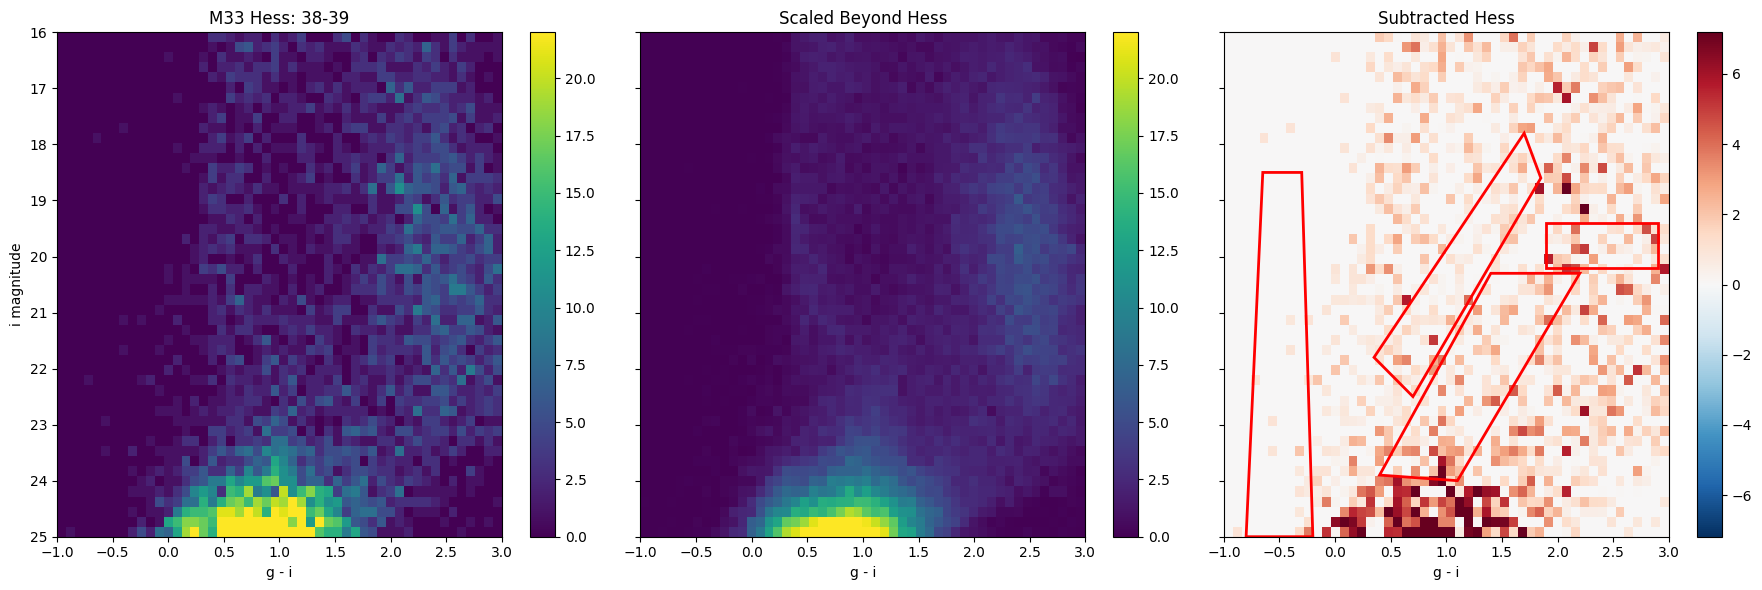

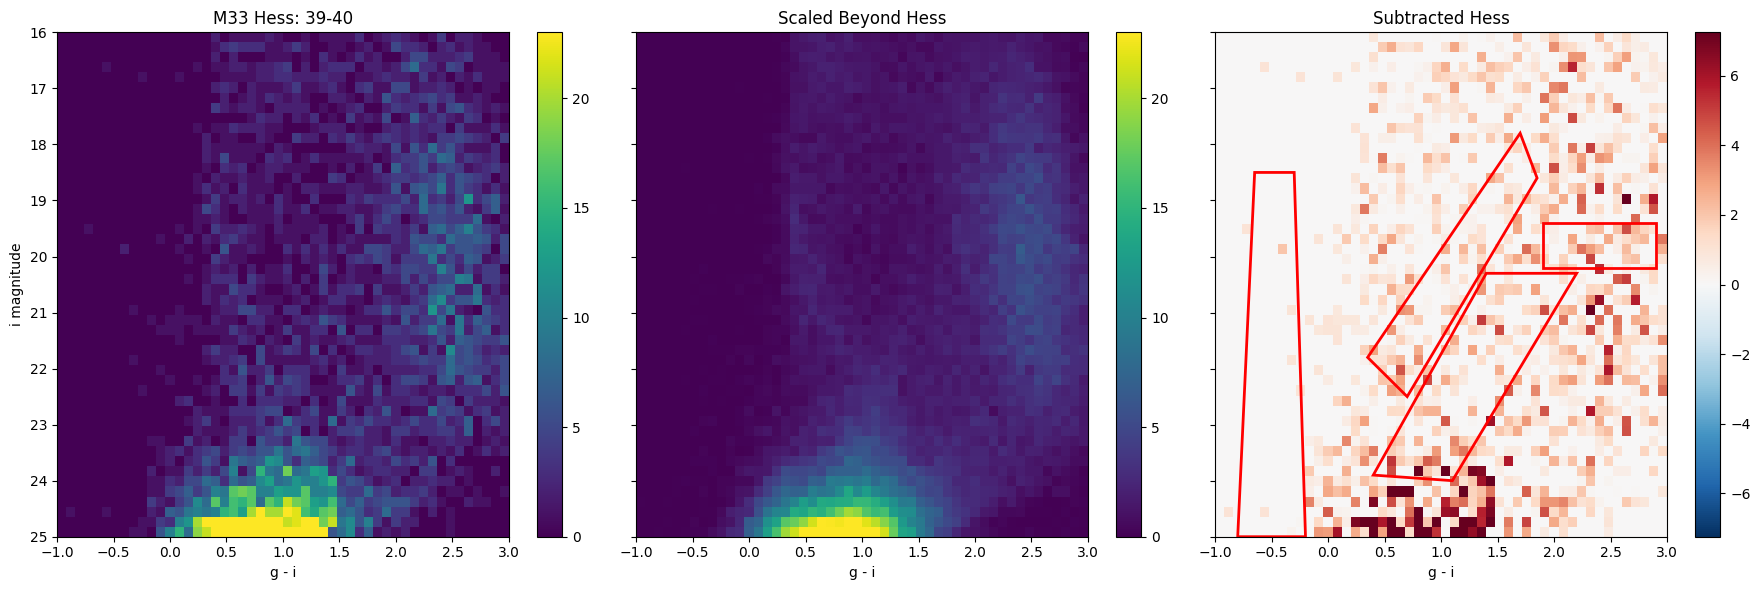

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon

# === Load processed CSV data ===
panda = pd.read_csv("panda_deproj.csv")

# === Define Area Functions ===
def elliptical_annulus_area_analytic(a_in_kpc, a_out_kpc, inc_deg):
    inc_rad = np.deg2rad(inc_deg)
    return np.pi * (a_out_kpc**2 - a_in_kpc**2) * np.cos(inc_rad)

def estimate_area_and_plot_annuli(n_points=1_00_000, max_radius_kpc=60,
                                   distance_kpc=859, PA_deg=112, inc_deg=52,
                                   area_rings=[], plot_radii_kpc=[]):
    def kpc_to_arcmin(kpc):
        return np.rad2deg(kpc / distance_kpc) * 60

    max_radius_rad = max_radius_kpc / distance_kpc
    max_radius_arcmin = np.rad2deg(max_radius_rad) * 60
    xi = np.random.uniform(-max_radius_arcmin, max_radius_arcmin, n_points)
    eta = np.random.uniform(-max_radius_arcmin, max_radius_arcmin, n_points)

    PA_rad = np.deg2rad(PA_deg)
    inc_rad = np.deg2rad(inc_deg)
    xi_rot = xi * np.cos(PA_rad) + eta * np.sin(PA_rad)
    eta_rot = -xi * np.sin(PA_rad) + eta * np.cos(PA_rad)
    eta_deproj = eta_rot / np.cos(inc_rad)
    r_arcmin = np.sqrt(xi_rot**2 + eta_deproj**2)

    areas = {}
    for a_in_kpc, a_out_kpc in area_rings:
        r_in = kpc_to_arcmin(a_in_kpc)
        r_out = kpc_to_arcmin(a_out_kpc)
        mask = (r_arcmin >= r_in) & (r_arcmin < r_out)
        n_inside = np.sum(mask)
        box_area_arcmin2 = (2 * max_radius_arcmin)**2
        arcmin2_to_sr = (np.pi / (180 * 60))**2
        box_area_sr = box_area_arcmin2 * arcmin2_to_sr
        box_area_kpc2 = box_area_sr * (distance_kpc ** 2)
        area_estimate = (n_inside / n_points) * box_area_kpc2
        areas[f"{a_in_kpc}-{a_out_kpc}"] = area_estimate

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(xi, eta, s=0.2, alpha=0.3, label='Random Points')
    for r_kpc in plot_radii_kpc:
        a = kpc_to_arcmin(r_kpc)
        b = a * np.cos(inc_rad)
        color = 'blue' if r_kpc < 40 else 'red'
        style = '--' if r_kpc % 2 == 0 else '-'
        ellipse = Ellipse((0, 0), width=2*a, height=2*b, angle=PA_deg,
                          edgecolor=color, linestyle=style, fill=False, label=f"{r_kpc} kpc")
        ax.add_patch(ellipse)

    ax.set_xlabel("ξ (arcmin)")
    ax.set_ylabel("η (arcmin)")
    ax.set_title("Deprojected Elliptical Annuli with Random Points")
    ax.set_aspect('equal')
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    return areas

def make_hess(df, bins=(50, 50)):
    hist, xedges, yedges = np.histogram2d(df['color'], df['mag'], bins=bins, range=[[-1, 3], [18, 25]])
    return hist

# === Define bins (2 kpc steps beyond 15) ===
radial_bins_kpc = [(r, r + 1) for r in range(3, 40)]
beyond_bin = (40, 50)
all_bins = radial_bins_kpc + [beyond_bin]

area_results = estimate_area_and_plot_annuli(
    n_points=100_000,
    max_radius_kpc=60,
    distance_kpc=859,
    PA_deg=112,
    inc_deg=52,
    area_rings=all_bins,
    plot_radii_kpc=[r for pair in all_bins for r in pair]
)

# === Print Area Comparison Table ===
print("\n=== Area Comparison for All Bins ===")
print(f"{'Bin (kpc)':<12} {'Analytic Area':>20} {'Monte Carlo Area':>25} {'% Diff':>10}")
print("-" * 75)
for (r_in, r_out) in all_bins:
    key = f"{r_in}-{r_out}"
    area_mc = area_results[key]
    area_an = elliptical_annulus_area_analytic(r_in, r_out, inc_deg=52)
    pct_diff = 100 * (area_mc - area_an) / area_an
    print(f"{key:<12} {area_an:>20.2f} {area_mc:>25.2f} {pct_diff:>10.2f}")

# === Subtract and Plot Hess Diagrams in Linear Scale ===
beyond_area = area_results[f"{beyond_bin[0]}-{beyond_bin[1]}"]
beyond_df = panda[(panda['r_deproj_kpc'] >= beyond_bin[0]) & (panda['r_deproj_kpc'] < beyond_bin[1])]
hess_beyond = make_hess(beyond_df)

for r_in, r_out in radial_bins_kpc:
    label = f"{r_in}-{r_out}"
    bin_df = panda[(panda['r_deproj_kpc'] >= r_in) & (panda['r_deproj_kpc'] < r_out)]
    hess_m33 = make_hess(bin_df)

    scale = area_results[label] / beyond_area
    hess_scaled_beyond = scale * hess_beyond
    hess_subtracted = hess_m33 - hess_scaled_beyond

    vlim = np.percentile(np.abs(hess_m33), 99)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    im0 = axes[0].imshow(hess_m33.T, origin='upper', aspect='auto',
                         extent=[-1, 3, 25, 16], cmap='viridis',
                         vmin=0, vmax=vlim)
    axes[0].set_title(f"M33 Hess: {label}")
    axes[0].set_xlabel('g - i')
    axes[0].set_ylabel('i magnitude')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(hess_scaled_beyond.T, origin='upper', aspect='auto',
                         extent=[-1, 3, 25, 16], cmap='viridis',
                         vmin=0, vmax=vlim)
    axes[1].set_title("Scaled Beyond Hess")
    axes[1].set_xlabel('g - i')
    fig.colorbar(im1, ax=axes[1])

    vlim_diff = np.percentile(np.abs(hess_subtracted), 99)
    hess_subtracted_clipped = np.clip(hess_subtracted, 0, None)
    im2 = axes[2].imshow(hess_subtracted_clipped.T, origin='upper', aspect='auto',
                        extent=[-1, 3, 25, 16], cmap='RdBu_r',
                        vmin=-vlim_diff, vmax=vlim_diff)
    axes[2].set_title("Subtracted Hess")
    axes[2].set_xlabel('g - i')
    fig.colorbar(im2, ax=axes[2])

    # === Add Estimated Red Polygons ===
    polygon_regions = [
        [(-0.8, 25), (-0.65, 18.5), (-0.3, 18.5), (-0.2, 25)],
        [(0.7, 22.5), (0.35, 21.8), (1.7, 17.8), (1.85, 18.6)],
        [(0.4, 23.9), (1.4, 20.3), (2.2, 20.3), (1.1, 24)],
        [(1.9, 19.4), (2.9, 19.4), (2.9, 20.2), (1.9, 20.2)]
    ]
    
    for poly in polygon_regions:
        patch = Polygon(poly, closed=True, edgecolor='red', facecolor='none', linewidth=2)
        axes[2].add_patch(patch)

    plt.tight_layout()
    plt.show()

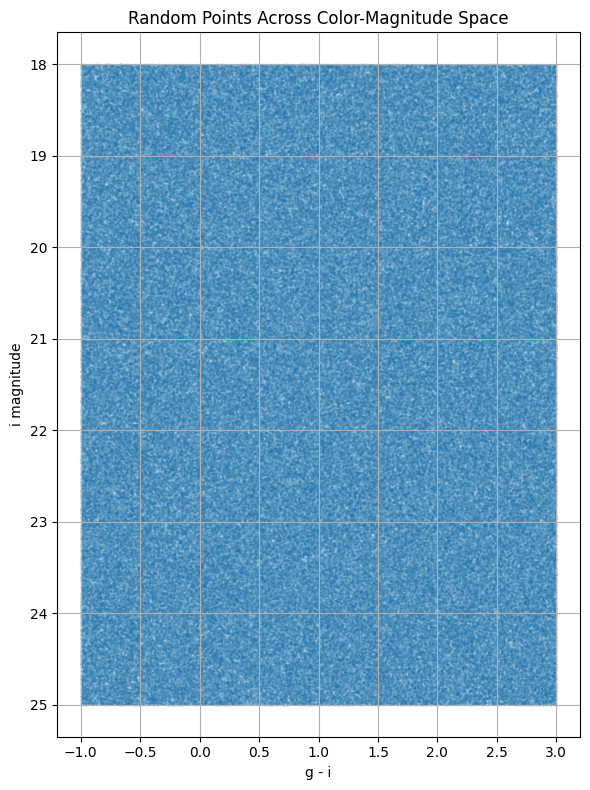

28

=== Monte Carlo Area Estimates for CMD Polygons ===
Polygon 1: Estimated area = 3.0888 mag² (fraction 0.110313)
Polygon 2: Estimated area = 1.9072 mag² (fraction 0.068115)
Polygon 3: Estimated area = 2.4362 mag² (fraction 0.087008)
Polygon 4: Estimated area = 0.8086 mag² (fraction 0.028877)


In [4]:
from matplotlib.path import Path

# === Monte Carlo estimate of polygon areas ===

# Step 1: Generate random points across the CMD plane
n_cmd_points = 1_000_000
color_range = [-1, 3]
mag_range = [18, 25]

rand_colors = np.random.uniform(color_range[0], color_range[1], n_cmd_points)
rand_mags = np.random.uniform(mag_range[0], mag_range[1], n_cmd_points)
cmd_points = np.vstack((rand_colors, rand_mags)).T

# Step 2: Define polygon regions again (must match what you plotted)
polygon_regions = [
    [(-0.8, 25), (-0.65, 18.5), (-0.3, 18.5), (-0.2, 25)],
    [(0.7, 22.5), (0.35, 21.8), (1.7, 17.8), (1.85, 18.6)],
    [(0.5, 23.9), (1.5, 20.3), (2.2, 20.3), (1.1, 24)],
    [(1.9, 19.4), (2.9, 19.4), (2.9, 20.2), (1.9, 20.2)],
]

plt.figure(figsize=(6, 8))
plt.scatter(rand_colors, rand_mags, s=0.1, alpha=0.2)
plt.gca().invert_yaxis()
plt.xlabel('g - i')
plt.ylabel('i magnitude')
plt.title('Random Points Across Color-Magnitude Space')
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 3: Estimate area using Monte Carlo
cmd_box_area = (color_range[1] - color_range[0]) * (mag_range[1] - mag_range[0])
print(cmd_box_area)
print("\n=== Monte Carlo Area Estimates for CMD Polygons ===")
for i, poly in enumerate(polygon_regions):
    path = Path(poly)
    mask = path.contains_points(cmd_points)
    frac_inside = np.sum(mask) / n_cmd_points
    poly_area = frac_inside * cmd_box_area
    print(f"Polygon {i+1}: Estimated area = {poly_area:.4f} mag² (fraction {frac_inside:.6f})")


In [5]:
from rich.table import Table
from rich.console import Console
from matplotlib.path import Path
import numpy as np

# === Extract CMD and radius values from your data ===
real_colors = panda['color'].values
real_mags = panda['mag'].values
real_radii = panda['r_deproj_kpc'].values
real_cmd_points = np.vstack((real_colors, real_mags)).T

# === Define the CMD polygon regions ===
polygon_regions = [
    [(-0.8, 25), (-0.65, 18.5), (-0.3, 18.5), (-0.2, 25)],
    [(0.7, 22.5), (0.35, 21.8), (1.7, 17.8), (1.85, 18.6)],
    [(0.5, 23.9), (1.5, 20.3), (2.2, 20.3), (1.1, 24)],
    [(1.9, 19.4), (2.9, 19.4), (2.9, 20.2), (1.9, 20.2)],
]



# === Precompute masks for each polygon
polygon_masks = [Path(poly).contains_points(real_cmd_points) for poly in polygon_regions]

# === Prepare Rich table
table = Table(title="Star Counts per Polygon by Radial Bin")
table.add_column("Bin (kpc)", justify="right")
for i in range(1, 5):
    table.add_column(f"Polygon {i}", justify="right")

# === Fill table
for r_in, r_out in radial_bins_kpc:
    radial_mask = (real_radii >= r_in) & (real_radii < r_out)
    row = [f"{r_in}-{r_out}"]
    for poly_mask in polygon_masks:
        count = np.sum(poly_mask & radial_mask)
        row.append(str(count))
    table.add_row(*row)

# === Display the table
console = Console()
console.print(table)

            Star Counts per Polygon by Radial Bin            
┏━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Bin (kpc) ┃ Polygon 1 ┃ Polygon 2 ┃ Polygon 3 ┃ Polygon 4 ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━┩
│       3-4 │      1879 │       916 │      4288 │       141 │
│       4-5 │      2806 │       872 │      7255 │       137 │
│       5-6 │      3429 │       960 │     11037 │       124 │
│       6-7 │      4140 │       796 │     13679 │       113 │
│       7-8 │      3183 │       465 │     14509 │       106 │
│       8-9 │      1009 │       172 │     11572 │        93 │
│      9-10 │       413 │       116 │      6237 │        90 │
│     10-11 │       225 │       114 │      3423 │        90 │
│     11-12 │       156 │       105 │      2578 │        85 │
│     12-13 │       115 │        93 │      2492 │       104 │
│     13-14 │        63 │       110 │      1618 │       138 │
│     14-15 │        44 │        91 │      1084 │       106 │
│     15-16 │        41 │       107 │       793 │       114 │
│     16-17 │        31 │       103 │       655 │       120 │
│     17-18 │        19 │       117 │       564 │       121 │
│     18-19 │        19 │       121 │       491 │       124 │
│     19-20 │        23 │       115 │       490 │       129 │
│     20-21 │        22 │       114 │       517 │       113 │
│     21-22 │        21 │       122 │       449 │       142 │
│     22-23 │        11 │       132 │       469 │       139 │
│     23-24 │        11 │       122 │       485 │       120 │
│     24-25 │        22 │       131 │       538 │       177 │
│     25-26 │        25 │       159 │       553 │       172 │
│     26-27 │        14 │       140 │       547 │       178 │
│     27-28 │        23 │       162 │       571 │       150 │
│     28-29 │        29 │       173 │       545 │       181 │
│     29-30 │        18 │       163 │       541 │       201 │
│     30-31 │        18 │       181 │       519 │       213 │
│     31-32 │        24 │       169 │       541 │       225 │
│     32-33 │        26 │       163 │       488 │       198 │
│     33-34 │        23 │       194 │       527 │       215 │
│     34-35 │        24 │       199 │       518 │       211 │
│     35-36 │        20 │       190 │       518 │       206 │
│     36-37 │        20 │       230 │       484 │       240 │
│     37-38 │        20 │       203 │       575 │       245 │
│     38-39 │        24 │       217 │       517 │       273 │
│     39-40 │         8 │       232 │       550 │       252 │
└───────────┴───────────┴───────────┴───────────┴───────────┘

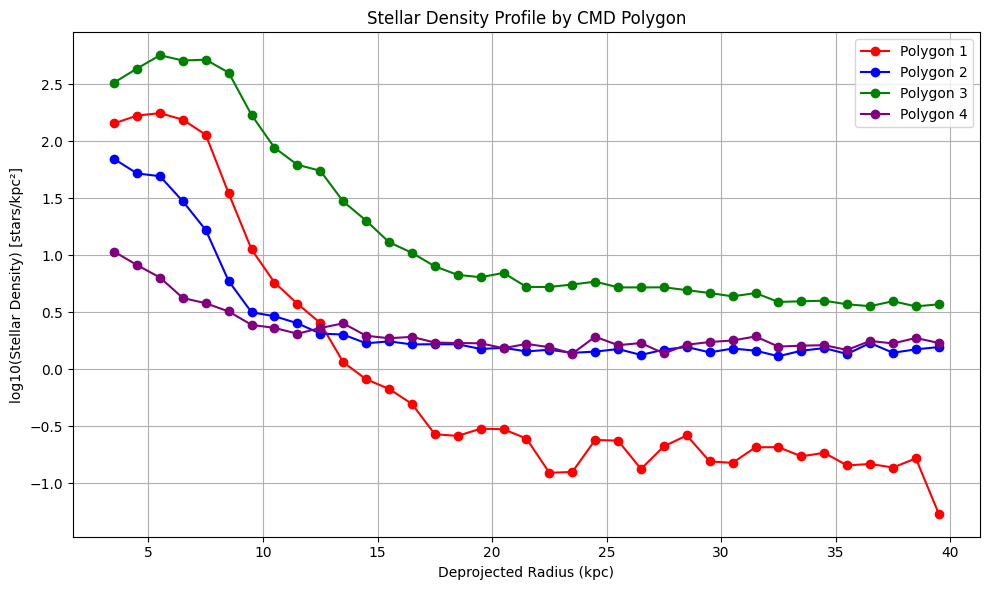

In [8]:
import matplotlib.pyplot as plt
import numpy as np


# Precompute bin midpoints and areas
bin_labels = [f"{r0}-{r1}" for (r0, r1) in radial_bins_kpc]
bin_midpoints = [(r0 + r1) / 2 for (r0, r1) in radial_bins_kpc]
bin_areas = [area_results[f"{r0}-{r1}"] for (r0, r1) in radial_bins_kpc]  # from your Monte Carlo output

# Recalculate star counts per polygon per bin
real_colors = panda['color'].values
real_mags = panda['mag'].values
real_radii = panda['r_deproj_kpc'].values
real_cmd_points = np.vstack((real_colors, real_mags)).T

polygon_regions = [
    [(-0.8, 25), (-0.65, 18.5), (-0.3, 18.5), (-0.2, 25)],
    [(0.7, 22.5), (0.35, 21.8), (1.7, 17.8), (1.85, 18.6)],
    [(0.5, 23.9), (1.5, 20.3), (2.2, 20.3), (1.1, 24)],
    [(1.9, 19.4), (2.9, 19.4), (2.9, 20.2), (1.9, 20.2)],
]
polygon_masks = [Path(poly).contains_points(real_cmd_points) for poly in polygon_regions]

# Collect densities
log_densities_per_poly = []
for mask in polygon_masks:
    log_densities = []
    for (r0, r1), area in zip(radial_bins_kpc, bin_areas):
        radial_mask = (real_radii >= r0) & (real_radii < r1)
        count = np.sum(mask & radial_mask)
        density = count / area if area > 0 else 0
        log_density = np.log10(density) if density > 0 else np.nan
        log_densities.append(log_density)
    log_densities_per_poly.append(log_densities)

# Plot
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'purple']
for i, log_densities in enumerate(log_densities_per_poly):
    plt.plot(bin_midpoints, log_densities, marker='o', label=f'Polygon {i+1}', color=colors[i])

plt.xlabel("Deprojected Radius (kpc)")
plt.ylabel("log10(Stellar Density) [stars/kpc²]")
plt.title("Stellar Density Profile by CMD Polygon")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
from matplotlib.path import Path

# Define polygon masks (already known CMD boxes)
polygon_paths = [Path(poly) for poly in polygon_regions]
beyond_area = area_results["40-50"]

# Prepare CMD points
real_cmd_points = np.vstack((panda['color'].values, panda['mag'].values)).T
real_radii = panda['r_deproj_kpc'].values
beyond_mask = (real_radii >= 40) & (real_radii < 50)

print("\n=== Foreground vs M33 Star Fractions by Radial Bin ===")
print(f"{'Bin (kpc)':<10} {'FG Stars':>10} {'M33 Stars':>10} {'Total':>10} {'FG/Total':>10} {'M33/Total':>12}")
print("-" * 70)

for r0, r1 in radial_bins_kpc:
    bin_key = f"{r0}-{r1}"
    bin_mask = (real_radii >= r0) & (real_radii < r1)
    bin_area = area_results[bin_key]
    area_ratio = bin_area / beyond_area

    fg_total = 0
    m33_total = 0

    for path in polygon_paths:
        # Foreground (from beyond bin)
        beyond_inside = path.contains_points(real_cmd_points[beyond_mask])
        fg_total += area_ratio * np.sum(beyond_inside)

        # M33 stars (from current bin)
        bin_inside = path.contains_points(real_cmd_points[bin_mask])
        m33_total += np.sum(bin_inside)

    total = fg_total + m33_total
    fg_frac = fg_total / total if total > 0 else np.nan
    m33_frac = m33_total / total if total > 0 else np.nan

    print(f"{bin_key:<10} {fg_total:10.1f} {m33_total:10.1f} {total:10.1f} {fg_frac:10.3f} {m33_frac:12.3f}")



=== Foreground vs M33 Star Fractions by Radial Bin ===
Bin (kpc)    FG Stars  M33 Stars      Total   FG/Total    M33/Total
----------------------------------------------------------------------
3-4              80.2     7224.0     7304.2      0.011        0.989
4-5             102.2    11070.0    11172.2      0.009        0.991
5-6             119.0    15550.0    15669.0      0.008        0.992
6-7             163.9    18728.0    18891.9      0.009        0.991
7-8             171.0    18263.0    18434.0      0.009        0.991
8-9             177.1    12846.0    13023.1      0.014        0.986
9-10            224.7     6856.0     7080.7      0.032        0.968
10-11           238.8     3852.0     4090.8      0.058        0.942
11-12           253.8     2924.0     3177.8      0.080        0.920
12-13           276.7     2804.0     3080.7      0.090        0.910
13-14           334.0     1929.0     2263.0      0.148        0.852
14-15           329.6     1325.0     1654.6      0.199   